# all

In [1]:
import pandas as pd
import os
import random
import chardet
import requests
import json
import numpy as np
from urllib3.util.retry import Retry
import openai
from requests.adapters import HTTPAdapter
import os
import pickle
import matplotlib.pyplot as plt
# from utils.read_group_danmu import read_group_danmu

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

/home/lzs/miniconda3/envs/lzs/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (1.26.15) or chardet (7.3.0)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import os

font_path = '/mnt/dataset0/lzs/.fonts/arial.ttf'  # 1) 路径要确认存在
assert os.path.exists(font_path), f"字体文件不存在: {font_path}"

# 2) 注册字体到 Matplotlib 的 fontManager（关键！）
fm.fontManager.addfont(font_path)

# 3) 读取这份 ttf 的“内部字体名”（可能是 Arial / ArialMT 等）
font_name = fm.FontProperties(fname=font_path).get_name()
print("Internal font name =", font_name)

# 4) 彻底避免去找 'Arial' 这个字符串
mpl.rcParams['font.family'] = [font_name]       # 用内部名
mpl.rcParams['font.sans-serif'] = [font_name]   # 避免回退到其他 sans-serif
mpl.rcParams['axes.unicode_minus'] = False

# （可选）如果你曾经设置过 'Arial'，先清理干净：
# mpl.rcParams['font.family'] = 'sans-serif'
# mpl.rcParams['font.sans-serif'] = [font_name]

# # 5) 画个图测试（坐标轴/标题/文字都应使用该字体，不再报错）
# plt.figure()
# plt.title('Title uses the registered font')
# plt.xlabel('X 轴')
# plt.ylabel('Y 轴')
# plt.text(0.5, 0.5, 'Hello Arial (from file)', ha='center', va='center')
# plt.show()


Internal font name = Arial


In [3]:
r_list=np.zeros(6)
r2_list=np.zeros(6)
p_list=np.zeros(6)
perm_rho_list = [[] for _ in range(6)]

## trajectory

In [4]:
with open(r'/mnt/dataset1/xinke/Danmu/DyEmo-film/Emotion_scores/scores_allMovies_resample.pkl', 'rb') as f:
    scores_dict = pickle.load(f)
# del scores_dict['BV1zW411d7Rb']
with open(r'/mnt/dataset1/xinke/Danmu/DyEmo-film/Emotion_scores/times_allMovies_resample.pkl', 'rb') as f:
    time_dict= pickle.load(f)
# del time_dict['BV1zW411d7Rb']

print(len(scores_dict.keys()))
print(len(time_dict.keys()))

102
102


In [5]:
scores_all = np.zeros((0,6))
n_samples = []

scores_key = list(scores_dict.keys())
count = 0
for key in scores_key:
    # print(scores_dict[key].shape)
    scores_all = np.concatenate((scores_all, scores_dict[key]), 0)
    n_samples.append(scores_dict[key].shape[0])
    count += 1
print(scores_all.shape)
n_samples_cum = np.concatenate((np.array([0]), np.cumsum(n_samples)))
print(n_samples_cum[-5:])

(356168, 6)
[343322 346152 349604 352228 356168]


In [6]:
import re
df = pd.read_csv('/mnt/dataset1/xinke/Danmu/DyEmo-film/movie_info_final3.csv')
bvid_list = df.loc[:18,'BVID'].tolist()+scores_key[18:-1]

In [7]:
from scipy.interpolate import interp1d

def resample_curve(curve, target_len=1000):
    """
    curve: np.ndarray, shape = (T, 6)
    return: np.ndarray, shape = (target_len, 6)
    """
    curve = np.asarray(curve)

    if curve.ndim != 2:
        raise ValueError(f"curve should be 2D, got shape {curve.shape}")

    T, D = curve.shape
    if D != 6:
        raise ValueError(f"Expected 6 dimensions, got {D}")

    old_x = np.linspace(0, 1, T)
    new_x = np.linspace(0, 1, target_len)

    f = interp1d(old_x, curve, axis=0, kind="linear")
    new_curve = f(new_x)

    return new_curve

In [8]:
curves = [resample_curve(scores_dict[key], target_len=2000) for key in scores_key]

In [9]:
np.array(curves).shape

(102, 2000, 6)

In [10]:
X_seq = np.array(curves)

In [11]:
X = np.array(curves).reshape(len(curves), -1)
X.shape

(102, 12000)

In [12]:
likes = np.array(pd.read_csv('movie_info_full.csv').loc[:,'coins'].tolist()[:102])
# coins = np.array(pd.read_csv('movie_info_full.csv').loc[:,'coins'].tolist()[:102])
# saves = np.array(pd.read_csv('movie_info_full.csv').loc[:,'saves'].tolist()[:102])
views = np.array(pd.read_csv('movie_info_full.csv').loc[:,'views'].tolist()[:102])
mask = (views == views)
# y = likes[mask]/views[mask] * 100
y = np.log1p(likes[mask])

In [13]:
# # 原始目标：点赞率
# y_raw = y

# # 对全部 y 做 Z-score
# y = (y_raw - np.mean(y_raw)) / np.std(y_raw)

# print("mean:", np.mean(y))
# print("std:", np.std(y))
# print(y)

In [14]:
# from scipy.stats import pearsonr,spearmanr
# pearsonr(likes[mask], coins[mask]),pearsonr(likes[mask], saves[mask]),pearsonr(coins[mask], saves[mask])

In [15]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

y = np.asarray(y).reshape(-1, 1)

y_scaler = MinMaxScaler(feature_range=(0, 1))
y_01 = y_scaler.fit_transform(y).ravel()

print(y_01.min(), y_01.max())
print(y_01[:10])

0.0 1.0
[0.55124545 0.79640479 0.68881486 0.         0.36551823 0.75653393
 0.52329258 0.5998585  0.6591059  0.99346832]


In [16]:
y.shape

(100, 1)

## static feature

In [17]:
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from scipy.stats import spearmanr, pearsonr
import numpy as np

X = np.array(curves)[likes == likes].mean(axis=1)
y = y_01

model = Pipeline([
    ("scaler", StandardScaler()),
    # ("pca", PCA(n_components=50, random_state=42)),
    ("svr", SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale"))
])

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    },
    return_train_score=True
)

print("Test R2:", scores["test_r2"])
print("Mean Test R2:", scores["test_r2"].mean())

print("Test MAE:", -scores["test_mae"])
print("Mean Test MAE:", -scores["test_mae"].mean())

print("Test RMSE:", -scores["test_rmse"])
print("Mean Test RMSE:", -scores["test_rmse"].mean())

# =========================
# 额外输出：交叉验证预测值 vs 真实值的 Spearman 相关
# =========================
y_pred_cv = cross_val_predict(
    model,
    X,
    y,
    cv=cv
)

rho, spearman_p = spearmanr(y, y_pred_cv)
r, pearson_p = pearsonr(y, y_pred_cv)

print("CV Spearman rho:", rho)
print("CV Spearman p:", spearman_p)

# print("CV Pearson r:", r)
# print("CV Pearson p:", pearson_p)

Test R2: [-0.08734604 -0.39880734  0.01887953 -0.33626386 -0.26167055]
Mean Test R2: -0.21304165309211393
Test MAE: [0.17094557 0.15309651 0.13279246 0.13027975 0.16186733]
Mean Test MAE: 0.14979632361181186
Test RMSE: [0.2170699  0.2046809  0.19210315 0.18616531 0.20553877]
Mean Test RMSE: 0.20111160624992022
CV Spearman rho: 0.12652865286528653
CV Spearman p: 0.20968677190270088


In [18]:
y_pred_cv = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

rho_obs, spearman_p = spearmanr(y, y_pred_cv)
r_obs, pearson_p = pearsonr(y, y_pred_cv)

print("\nObserved CV Spearman rho:", rho_obs)
print("Standard Spearman p:", spearman_p)
N_PERM = 1000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

perm_rhos = np.zeros(N_PERM)

for i in range(N_PERM):

    # ----------------------------------------
    # Randomly shuffle labels
    # ----------------------------------------
    y_perm = rng.permutation(y)

    # ----------------------------------------
    # Re-train + CV prediction
    # ----------------------------------------
    y_pred_perm = cross_val_predict(
        model,
        X,
        y_perm,
        cv=cv,
        n_jobs=-1
    )

    # ----------------------------------------
    # Prediction performance under null
    # ----------------------------------------
    perm_rhos[i], _ = spearmanr(
        y_perm,
        y_pred_perm
    )

    # if (i + 1) % 100 == 0:
    #     print(
    #         f"Permutation {i + 1:4d}/{N_PERM}: "
    #         f"rho = {perm_rhos[i]:.4f}"
    #     )


# ============================================================
# One-sided permutation p-value
# H1: observed rho > random rho
# ============================================================

perm_p = (
    np.sum(perm_rhos >= rho_obs) + 1
) / (
    N_PERM + 1
)

print("\n======================================")
print("Observed rho :", rho_obs)
print("Permutation mean rho :", perm_rhos.mean())
print("Permutation std rho  :", perm_rhos.std())
print("Permutation p-value  :", perm_p)
print("======================================")


# ============================================================
# Output first 100 permutation results
# ============================================================

print("\nFirst 100 permutation rho values:")

# for i, rho_perm in enumerate(perm_rhos[:100]):
#     print(
#         f"{i + 1:03d}: "
#         f"{rho_perm:.4f}"
#     )


Observed CV Spearman rho: 0.12652865286528653
Standard Spearman p: 0.20968677190270088

Observed rho : 0.12652865286528653
Permutation mean rho : -0.02035409540954095
Permutation std rho  : 0.1443409298962911
Permutation p-value  : 0.16483516483516483

First 100 permutation rho values:


In [19]:
r_list[-1] = rho
r2_list[-1] = scores["test_r2"].mean()
p_list[-1] = spearman_p
perm_rho_list[-1] = perm_rhos

In [20]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# X: shape = (n_movie, 6)
# y: shape = (n_movie,)
X = np.array(curves)[likes==likes].mean(axis=1).astype(np.float32)
y = np.asarray(y_01).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=seed
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)


class MLPRegressor(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, dropout=0.3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),

            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


model = MLPRegressor(
    input_dim=6,
    hidden_dim=64,
    dropout=0.3
)

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("MLP trainable params:", count_trainable_params(model))

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-3
)

epochs = 500

for epoch in range(epochs):
    model.train()

    pred = model(X_train_t)
    loss = criterion(pred, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        model.eval()
        with torch.no_grad():
            train_pred = model(X_train_t).cpu().numpy()
            test_pred = model(X_test_t).cpu().numpy()

        train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
        test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
        test_mae = mean_absolute_error(y_test, test_pred)
        test_r2 = r2_score(y_test, test_pred)

        train_spearman = spearmanr(y_train, train_pred).correlation
        test_spearman = spearmanr(y_test, test_pred).correlation

        print(
            f"Epoch {epoch+1:03d} | "
            f"loss={loss.item():.4f} | "
            f"train_rmse={train_rmse:.4f} | "
            f"test_rmse={test_rmse:.4f} | "
            f"test_mae={test_mae:.4f} | "
            f"test_r2={test_r2:.4f} | "
            f"train_spearman={train_spearman:.4f} | "
            f"test_spearman={test_spearman:.4f}"
        )

MLP trainable params: 6721
Epoch 050 | loss=0.0352 | train_rmse=0.1706 | test_rmse=0.2364 | test_mae=0.1836 | test_r2=-0.2893 | train_spearman=0.3622 | test_spearman=-0.0060
Epoch 100 | loss=0.0266 | train_rmse=0.1476 | test_rmse=0.2396 | test_mae=0.1820 | test_r2=-0.3250 | train_spearman=0.5380 | test_spearman=0.1759
Epoch 150 | loss=0.0332 | train_rmse=0.1343 | test_rmse=0.2419 | test_mae=0.1786 | test_r2=-0.3500 | train_spearman=0.6135 | test_spearman=0.1519
Epoch 200 | loss=0.0206 | train_rmse=0.1232 | test_rmse=0.2392 | test_mae=0.1756 | test_r2=-0.3207 | train_spearman=0.6614 | test_spearman=0.1474
Epoch 250 | loss=0.0166 | train_rmse=0.1170 | test_rmse=0.2422 | test_mae=0.1749 | test_r2=-0.3538 | train_spearman=0.7387 | test_spearman=0.1098
Epoch 300 | loss=0.0135 | train_rmse=0.1098 | test_rmse=0.2421 | test_mae=0.1755 | test_r2=-0.3525 | train_spearman=0.7858 | test_spearman=0.0571
Epoch 350 | loss=0.0136 | train_rmse=0.1061 | test_rmse=0.2423 | test_mae=0.1746 | test_r2=-0.35

## Dynamic Feature

In [21]:
dy_feature = np.concatenate([np.load('/mnt/dataset1/xinke/Danmu/Code_submit/results/MC_all.npy'), 
                             np.load('/mnt/dataset1/xinke/Danmu/Code_submit/results/AC_all.npy'),
                                np.load('/mnt/dataset1/xinke/Danmu/Code_submit/results/instability_all.npy'),
                                np.load('/mnt/dataset1/xinke/Danmu/Code_submit/results/Hurst_all.npy'),
                                np.load('/mnt/dataset1/xinke/Danmu/Code_submit/results/lambda_movies.npy')
                             ],axis=-1)[mask]


In [22]:
coins = np.array(pd.read_csv('movie_info_full.csv').loc[:,'coins'].tolist()[:102])
# coins = np.array(pd.read_csv('movie_info_full.csv').loc[:,'coins'].tolist()[:102])
# saves = np.array(pd.read_csv('movie_info_full.csv').loc[:,'saves'].tolist()[:102])
views = np.array(pd.read_csv('movie_info_full.csv').loc[:,'views'].tolist()[:102])
mask = (views == views)
# y = likes[mask]/views[mask] * 100
y_coins = np.log1p(coins[mask])

In [23]:
mask_dy = ~np.isnan(np.sum(dy_feature,axis=-1)) 

In [24]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.decomposition import PCA

model = Pipeline([
    ("scaler", StandardScaler()),
    #("pca", PCA(n_components=50, random_state=42)),
    ("svr", SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale"))
])

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    model,
    dy_feature[mask_dy],
    y_01[mask_dy],
    cv=cv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    },
    return_train_score=True
)

print("Test R2:", scores["test_r2"])
print("Mean Test R2:", scores["test_r2"].mean())

print("Test MAE:", -scores["test_mae"])
print("Mean Test MAE:", -scores["test_mae"].mean())

print("Test RMSE:", -scores["test_rmse"])
print("Mean Test RMSE:", -scores["test_rmse"].mean())



Test R2: [0.0380311  0.09714647 0.19846888 0.11967659 0.18226827]
Mean Test R2: 0.127118262338796
Test MAE: [0.12651312 0.16458872 0.13798945 0.11796381 0.13307853]
Mean Test MAE: 0.13602672746047606
Test RMSE: [0.15175129 0.20981186 0.18344946 0.15357195 0.15725131]
Mean Test RMSE: 0.17116717519791874


In [25]:
rho_list = []
scores_list = []
spearman_p_list = []
for i in range(5):
    model = Pipeline([
        ("scaler", StandardScaler()),
        #("pca", PCA(n_components=50, random_state=42)),
        ("svr", SVR(kernel="rbf", C=1, epsilon=0.1, gamma="scale"))
    ])

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_validate(
        model,
        dy_feature[mask_dy,i*6:(i+1)*6],
        y_01[mask_dy],
        cv=cv,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error"
        },
        return_train_score=True
    )

    print("Test R2:", scores["test_r2"])
    print("Mean Test R2:", scores["test_r2"].mean())
    scores_list.append(scores["test_r2"].mean())

    y_pred_cv = cross_val_predict(
        model,
        dy_feature[mask_dy,i*6:(i+1)*6],
        y_01[mask_dy],
        cv=cv
    )

    rho, spearman_p = spearmanr(y_01[mask_dy], y_pred_cv)
    print(f"Feature group {i+1} Spearman rho:", rho)
    rho_list.append(rho)
    spearman_p_list.append(spearman_p)
    
    # print("Test MAE:", -scores["test_mae"])
    # print("Mean Test MAE:", -scores["test_mae"].mean())

    # print("Test RMSE:", -scores["test_rmse"])
    # print("Mean Test RMSE:", -scores["test_rmse"].mean())



Test R2: [-0.17001456  0.04728163 -0.00902445 -0.44367013 -0.34377255]
Mean Test R2: -0.18384001231830766
Feature group 1 Spearman rho: 0.12478880961944287
Test R2: [-0.69095751 -0.2705054  -0.09626398 -0.59667414 -0.24752955]
Mean Test R2: -0.38038611724955684
Feature group 2 Spearman rho: 0.0668349814152465
Test R2: [-0.4776061  -0.38595089 -0.39635016 -0.33468759  0.15138092]
Mean Test R2: -0.2886427624668283
Feature group 3 Spearman rho: 0.028326607118948792
Test R2: [-0.1257344  -0.03878108 -0.17934639 -0.09378272 -0.0195571 ]
Mean Test R2: -0.09144033761101782
Feature group 4 Spearman rho: 0.13683861548368176
Test R2: [-0.05590065  0.35144982  0.13348991  0.14513541  0.04053666]
Mean Test R2: 0.12294222975888576
Feature group 5 Spearman rho: 0.3974204489668407


In [26]:
r_list[1] = rho_list[-1]
r2_list[1] = scores_list[-1]
p_list[1] = spearman_p_list[-1]

r_list[2] = rho_list[-3]
r2_list[2] = scores_list[-3]
p_list[2] = spearman_p_list[-3]

r_list[3] = rho_list[-4]
r2_list[3] = scores_list[-4]
p_list[3] = spearman_p_list[-4]

r_list[4] = rho_list[-5]
r2_list[4] = scores_list[-5]
p_list[4] = spearman_p_list[-5]

r_list, r2_list,p_list

(array([0.        , 0.39742045, 0.02832661, 0.06683498, 0.12478881,
        0.12652865]),
 array([ 0.        ,  0.12294223, -0.28864276, -0.38038612, -0.18384001,
        -0.21304165]),
 array([0.00000000e+00, 5.07836372e-05, 7.81874767e-01, 5.13192265e-01,
        2.20843595e-01, 2.09686772e-01]))

In [27]:
rho_list = []
scores_list = []
perm_p_list = []
perm_rho_group_list = []
N_PERM = 1000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

for i in range(5):

    # ============================================================
    # Data for current feature group
    # ============================================================

    X = dy_feature[mask_dy, i * 6:(i + 1) * 6]
    y = y_01[mask_dy]

    # ============================================================
    # Model
    # ============================================================

    model = Pipeline([
        ("scaler", StandardScaler()),
        # ("pca", PCA(n_components=50, random_state=42)),
        ("svr", SVR(
            kernel="rbf",
            C=1,
            epsilon=0.1,
            gamma="scale"
        ))
    ])

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # ============================================================
    # Original model performance
    # ============================================================

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error"
        },
        return_train_score=True,
        n_jobs=-1
    )

    mean_r2 = scores["test_r2"].mean()

    print(f"\nFeature group {i + 1}")
    print("Test R2:", scores["test_r2"])
    print("Mean Test R2:", mean_r2)

    scores_list.append(mean_r2)

    # ============================================================
    # Original cross-validation prediction
    # ============================================================

    y_pred_cv = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        n_jobs=-1
    )

    rho_obs, _ = spearmanr(y, y_pred_cv)

    print("Observed Spearman rho:", rho_obs)

    rho_list.append(rho_obs)

    # ============================================================
    # Permutation test
    # ============================================================

    perm_rhos = np.zeros(N_PERM)

    for p in range(N_PERM):

        # Randomly shuffle y labels
        y_perm = rng.permutation(y)

        # Entire CV prediction procedure is repeated
        y_pred_perm = cross_val_predict(
            model,
            X,
            y_perm,
            cv=cv,
            n_jobs=-1
        )

        # Spearman rho under null hypothesis
        perm_rhos[p], _ = spearmanr(
            y_perm,
            y_pred_perm
        )

        # if (p + 1) % 100 == 0:
        #     print(
        #         f"  Permutation {p + 1:4d}/{N_PERM}, "
        #         f"rho = {perm_rhos[p]:.4f}"
        #     )

    # ============================================================
    # One-sided permutation p-value
    # H1: observed prediction rho > random rho
    # ============================================================

    perm_p = (
        np.sum(perm_rhos >= rho_obs) + 1
    ) / (
        N_PERM + 1
    )

    print("Permutation mean rho:", perm_rhos.mean())
    print("Permutation std rho :", perm_rhos.std())
    print("Permutation p-value :", perm_p)

    # ============================================================
    # Save permutation results
    # ============================================================

    perm_p_list.append(perm_p)
    perm_rho_group_list.append(perm_rhos.copy())


# ============================================================
# Update your original result lists
#
# 保持你原来完全相同的 feature 对应关系：
#
# rho_list[-1] = group 5
# rho_list[-3] = group 3
# rho_list[-4] = group 2
# rho_list[-5] = group 1
# ============================================================

# Inertia <- group 5
r_list[1] = rho_list[-1]
r2_list[1] = scores_list[-1]
p_list[1] = perm_p_list[-1]
perm_rho_list[1] = perm_rho_group_list[-1].copy()


# Instability <- group 3
r_list[2] = rho_list[-3]
r2_list[2] = scores_list[-3]
p_list[2] = perm_p_list[-3]
perm_rho_list[2] = perm_rho_group_list[-3].copy()


# Modal controllability <- group 2
r_list[3] = rho_list[-4]
r2_list[3] = scores_list[-4]
p_list[3] = perm_p_list[-4]
perm_rho_list[3] = perm_rho_group_list[-4].copy()


# Average controllability <- group 1
r_list[4] = rho_list[-5]
r2_list[4] = scores_list[-5]
p_list[4] = perm_p_list[-5]
perm_rho_list[4] = perm_rho_group_list[-5].copy()


# ============================================================
# Check
# ============================================================

print("\nr_list:")
print(r_list)

print("\nr2_list:")
print(r2_list)

print("\np_list (permutation p-values):")
print(p_list)

print("\nNumber of permutation distributions:")
print(len(perm_rho_list))

print("\nPermutation rho shapes:")
print([
    None if x is None else np.asarray(x).shape
    for x in perm_rho_list
])


Feature group 1
Test R2: [-0.17001456  0.04728163 -0.00902445 -0.44367013 -0.34377255]
Mean Test R2: -0.18384001231830766
Observed Spearman rho: 0.12478880961944287


Permutation mean rho: -0.019162748885871123
Permutation std rho : 0.13217738084941283
Permutation p-value : 0.13986013986013987

Feature group 2
Test R2: [-0.69095751 -0.2705054  -0.09626398 -0.59667414 -0.24752955]
Mean Test R2: -0.38038611724955684
Observed Spearman rho: 0.0668349814152465
Permutation mean rho: -0.02003467028798398
Permutation std rho : 0.13396819146243713
Permutation p-value : 0.26073926073926074

Feature group 3
Test R2: [-0.4776061  -0.38595089 -0.39635016 -0.33468759  0.15138092]
Mean Test R2: -0.2886427624668283
Observed Spearman rho: 0.028326607118948792
Permutation mean rho: -0.02536471383304962
Permutation std rho : 0.1327354821023056
Permutation p-value : 0.33766233766233766

Feature group 4
Test R2: [-0.1257344  -0.03878108 -0.17934639 -0.09378272 -0.0195571 ]
Mean Test R2: -0.09144033761101782
Observed Spearman rho: 0.13683861548368176
Permutation mean rho: -0.021117418663810412
Permutation std rho : 0.135775930564304
Permutation p-value : 0.12587412587412

/tmp/ipykernel_1178764/1554631705.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


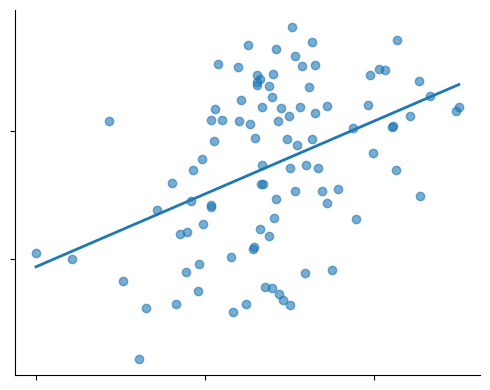

In [28]:
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import MaxNLocator

x = np.asarray(y_01[mask_dy]).reshape(-1, 1)
y = np.asarray(y_pred_cv)

reg = LinearRegression()
reg.fit(x, y)

x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
y_line = reg.predict(x_line)

r2 = reg.score(x, y)

fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(y_01[mask_dy], y_pred_cv, alpha=0.6)

ax.plot(
    x_line.ravel(),
    y_line,
    linewidth=2,
    #label=f"Linear fit, $R^2$ = {r2:.3f}"
)

# ax.set_xlabel("Real Values")
# ax.set_ylabel("Predicted Values")
# ax.set_title('Use RNN Predictions')
# 去掉上边框和右边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xticklabels([])
ax.set_yticklabels([])
# 每个坐标轴最多保留 3 个刻度
ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
#ax.set_title('Movie Likes Prediction from Emotional Dynamics')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [29]:
spearmanr(y_01[mask_dy], y_pred_cv)

SignificanceResult(statistic=0.3974204489668407, pvalue=5.078363718863213e-05)

Full model rho: 0.376
Happiness       | without rho = 0.408 | contribution = -0.032
Surprise        | without rho = 0.209 | contribution = 0.168
Sadness         | without rho = 0.331 | contribution = 0.046
Anger           | without rho = 0.421 | contribution = -0.045
Disgust         | without rho = 0.329 | contribution = 0.047
Fear            | without rho = 0.408 | contribution = -0.032

Full model rho: 0.376
Happiness: without=0.408, Δrho=-0.032
Surprise: without=0.209, Δrho=0.168
Sadness: without=0.331, Δrho=0.046
Anger: without=0.421, Δrho=-0.045
Disgust: without=0.329, Δrho=0.047
Fear: without=0.408, Δrho=-0.032


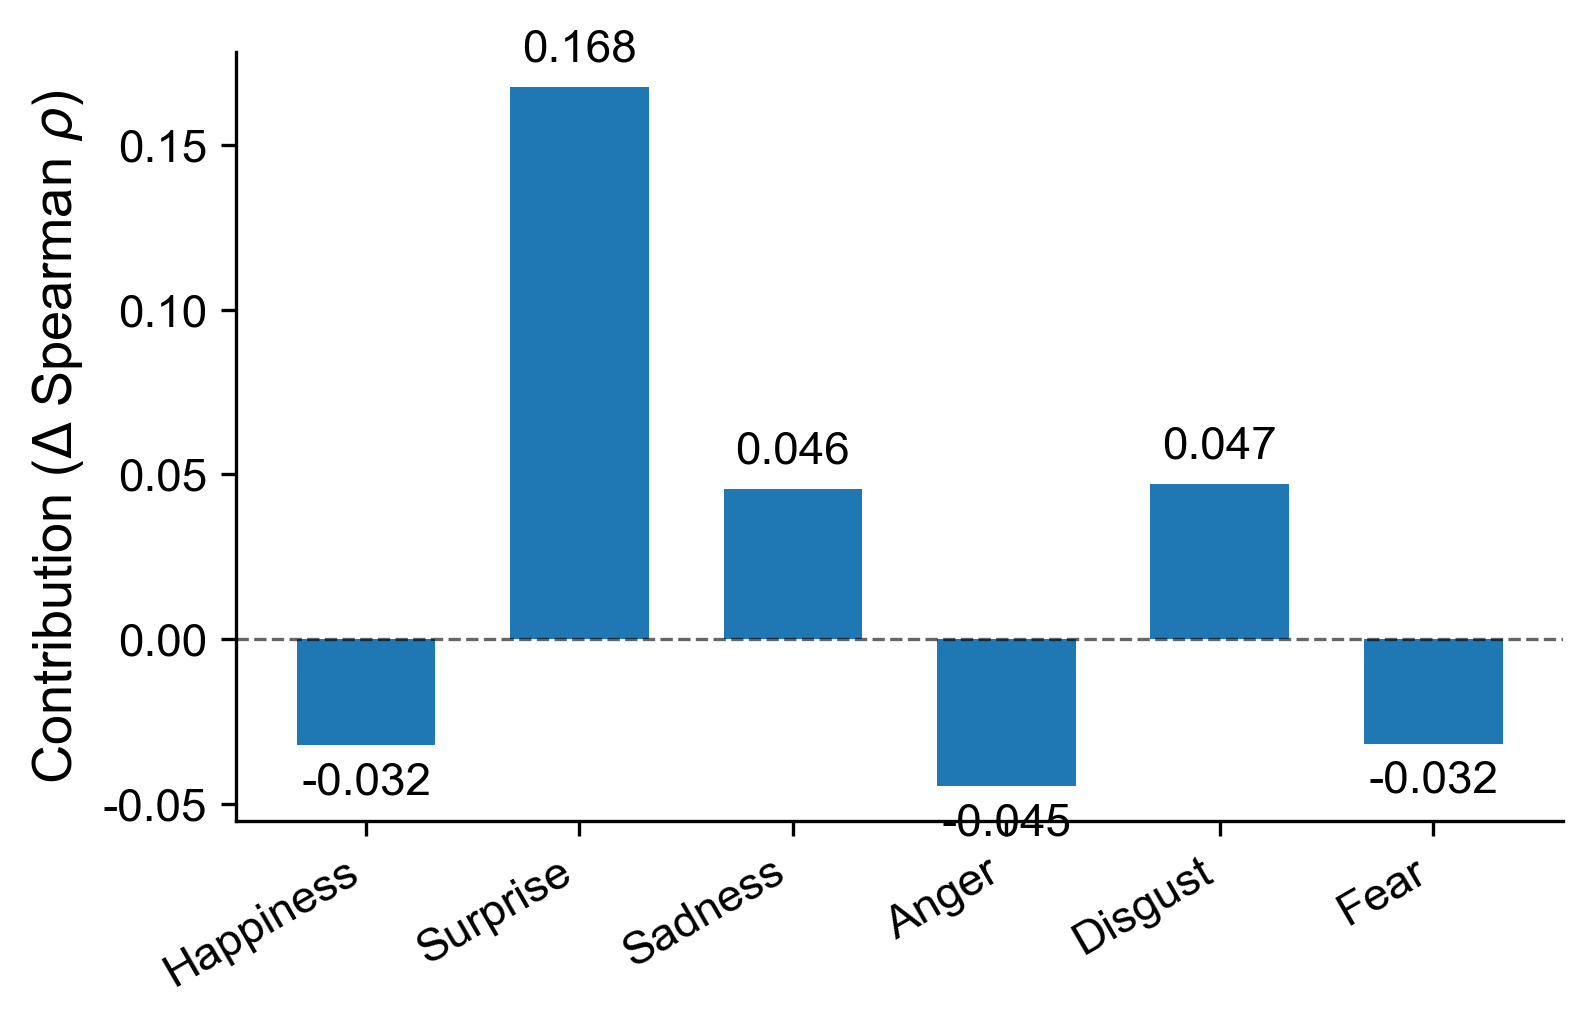

In [30]:

# ============================================================
# Settings
# ============================================================

# 按你实际的六种情绪顺序修改
emotion_names = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
n_emotions = 6

# dy_feature 中一共有多少组 feature
n_feature_groups = dy_feature.shape[1] // n_emotions

X = dy_feature[mask_dy]
y = y_01[mask_dy]


# ============================================================
# Model
# ============================================================

def get_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(
            kernel="rbf",
            C=1,
            epsilon=0.1,
            gamma="scale"
        ))
    ])


cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 1. Full model: all six emotions
# ============================================================

model = get_model()

y_pred_full = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

rho_full, _ = spearmanr(
    y,
    y_pred_full
)

print(f"Full model rho: {rho_full:.3f}")


# ============================================================
# 2. Leave-one-emotion-out
# ============================================================

rho_without = []
contribution = []

for emotion_idx in range(n_emotions):

    # --------------------------------------------------------
    # 找出该 emotion 在所有 feature groups 中对应的列
    #
    # 例如 emotion_idx = 2:
    # 2, 8, 14, 20, 26 ...
    # --------------------------------------------------------

    remove_cols = [
        group_idx * n_emotions + emotion_idx
        for group_idx in range(n_feature_groups)
    ]

    # 保留其他所有列
    keep_cols = [
        col
        for col in range(X.shape[1])
        if col not in remove_cols
    ]

    X_leave_out = X[:, keep_cols]

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    model = get_model()

    y_pred = cross_val_predict(
        model,
        X_leave_out,
        y,
        cv=cv,
        n_jobs=-1
    )

    rho, _ = spearmanr(
        y,
        y_pred
    )

    rho_without.append(rho)

    # --------------------------------------------------------
    # Contribution
    # Full rho - rho after removing this emotion
    # --------------------------------------------------------

    delta_rho = rho_full - rho

    contribution.append(delta_rho)

    print(
        f"{emotion_names[emotion_idx]:<15} | "
        f"without rho = {rho:.3f} | "
        f"contribution = {delta_rho:.3f}"
    )


rho_without = np.asarray(rho_without)
contribution = np.asarray(contribution)


# ============================================================
# 3. Results
# ============================================================

print("\n======================================")
print("Full model rho:", round(rho_full, 3))

for emotion, rho, delta in zip(
    emotion_names,
    rho_without,
    contribution
):
    print(
        f"{emotion}: "
        f"without={rho:.3f}, "
        f"Δrho={delta:.3f}"
    )


# ============================================================
# 4. Bar plot
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 13

fig, ax = plt.subplots(
    figsize=(5.5, 3.6),
    dpi=300
)

x = np.arange(len(emotion_names))

bars = ax.bar(
    x,
    contribution,
    width=0.65,
    edgecolor="none"
)

# rho = 0
ax.axhline(
    0,
    linestyle="--",
    color="black",
    linewidth=0.8,
    alpha=0.6
)

# ------------------------------------------------------------
# Value labels
# ------------------------------------------------------------

for bar, value in zip(bars, contribution):

    x_pos = bar.get_x() + bar.get_width() / 2

    if value >= 0:
        y_pos = value + 0.005
        va = "bottom"
    else:
        y_pos = value - 0.005
        va = "top"

    ax.text(
        x_pos,
        y_pos,
        f"{value:.3f}",
        ha="center",
        va=va,
        fontsize=11
    )


# ============================================================
# Axis
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    emotion_names,
    rotation=30,
    ha="right",
    fontsize=12
)

ax.set_ylabel(
    r"Contribution ($\Delta$ Spearman $\rho$)",
    fontsize=13
)

ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="both",
    labelsize=11
)

plt.tight_layout()

plt.savefig(
    "emotion_contribution.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "emotion_contribution.pdf",
    bbox_inches="tight"
)

plt.show()

In [31]:
from scipy.stats import spearmanr
import numpy as np

# 5 metrics × 6 emotions
metrics = [
    "MC",
    "AC",
    "Instability",
    "Hurst",
    "Lambda"
]

emotions = [
    "Happiness",
    "Surprise",
    "Sadness",
    "Anger",
    "Disgust",
    "Fear"
]

# 


rho_matrix = np.zeros((5, 6))
p_matrix = np.zeros((5, 6))

for i, metric in enumerate(metrics):
    for j, emotion in enumerate(emotions):

        idx = i * 6 + j

        rho, p = spearmanr(
            X[:, idx],
            y,
            nan_policy="omit"
        )

        rho_matrix[i, j] = rho
        p_matrix[i, j] = p

        print(
            f"{metric:12s} | {emotion:10s} | "
            f"rho = {rho:.3f}, p = {p:.3e}"
        )

MC           | Happiness  | rho = -0.081, p = 4.281e-01
MC           | Surprise   | rho = -0.102, p = 3.167e-01
MC           | Sadness    | rho = -0.163, p = 1.087e-01
MC           | Anger      | rho = 0.037, p = 7.195e-01
MC           | Disgust    | rho = 0.079, p = 4.392e-01
MC           | Fear       | rho = -0.065, p = 5.237e-01
AC           | Happiness  | rho = -0.125, p = 2.214e-01
AC           | Surprise   | rho = -0.056, p = 5.849e-01
AC           | Sadness    | rho = 0.135, p = 1.855e-01
AC           | Anger      | rho = -0.170, p = 9.332e-02
AC           | Disgust    | rho = -0.210, p = 3.827e-02
AC           | Fear       | rho = -0.082, p = 4.225e-01
Instability  | Happiness  | rho = -0.265, p = 8.422e-03
Instability  | Surprise   | rho = -0.133, p = 1.905e-01
Instability  | Sadness    | rho = 0.178, p = 7.873e-02
Instability  | Anger      | rho = -0.289, p = 3.881e-03
Instability  | Disgust    | rho = -0.348, p = 4.533e-04
Instability  | Fear       | rho = -0.082, p = 4.249e

MC           | Happiness  | rho = -0.081, p = 4.281e-01
MC           | Surprise   | rho = -0.102, p = 3.167e-01
MC           | Sadness    | rho = -0.163, p = 1.087e-01
MC           | Anger      | rho = 0.037, p = 7.195e-01
MC           | Disgust    | rho = 0.079, p = 4.392e-01
MC           | Fear       | rho = -0.065, p = 5.237e-01
AC           | Happiness  | rho = -0.125, p = 2.214e-01
AC           | Surprise   | rho = -0.056, p = 5.849e-01
AC           | Sadness    | rho = 0.135, p = 1.855e-01
AC           | Anger      | rho = -0.170, p = 9.332e-02
AC           | Disgust    | rho = -0.210, p = 3.827e-02
AC           | Fear       | rho = -0.082, p = 4.225e-01
Instability  | Happiness  | rho = -0.265, p = 8.422e-03
Instability  | Surprise   | rho = -0.133, p = 1.905e-01
Instability  | Sadness    | rho = 0.178, p = 7.873e-02
Instability  | Anger      | rho = -0.289, p = 3.881e-03
Instability  | Disgust    | rho = -0.348, p = 4.533e-04
Instability  | Fear       | rho = -0.082, p = 4.249e

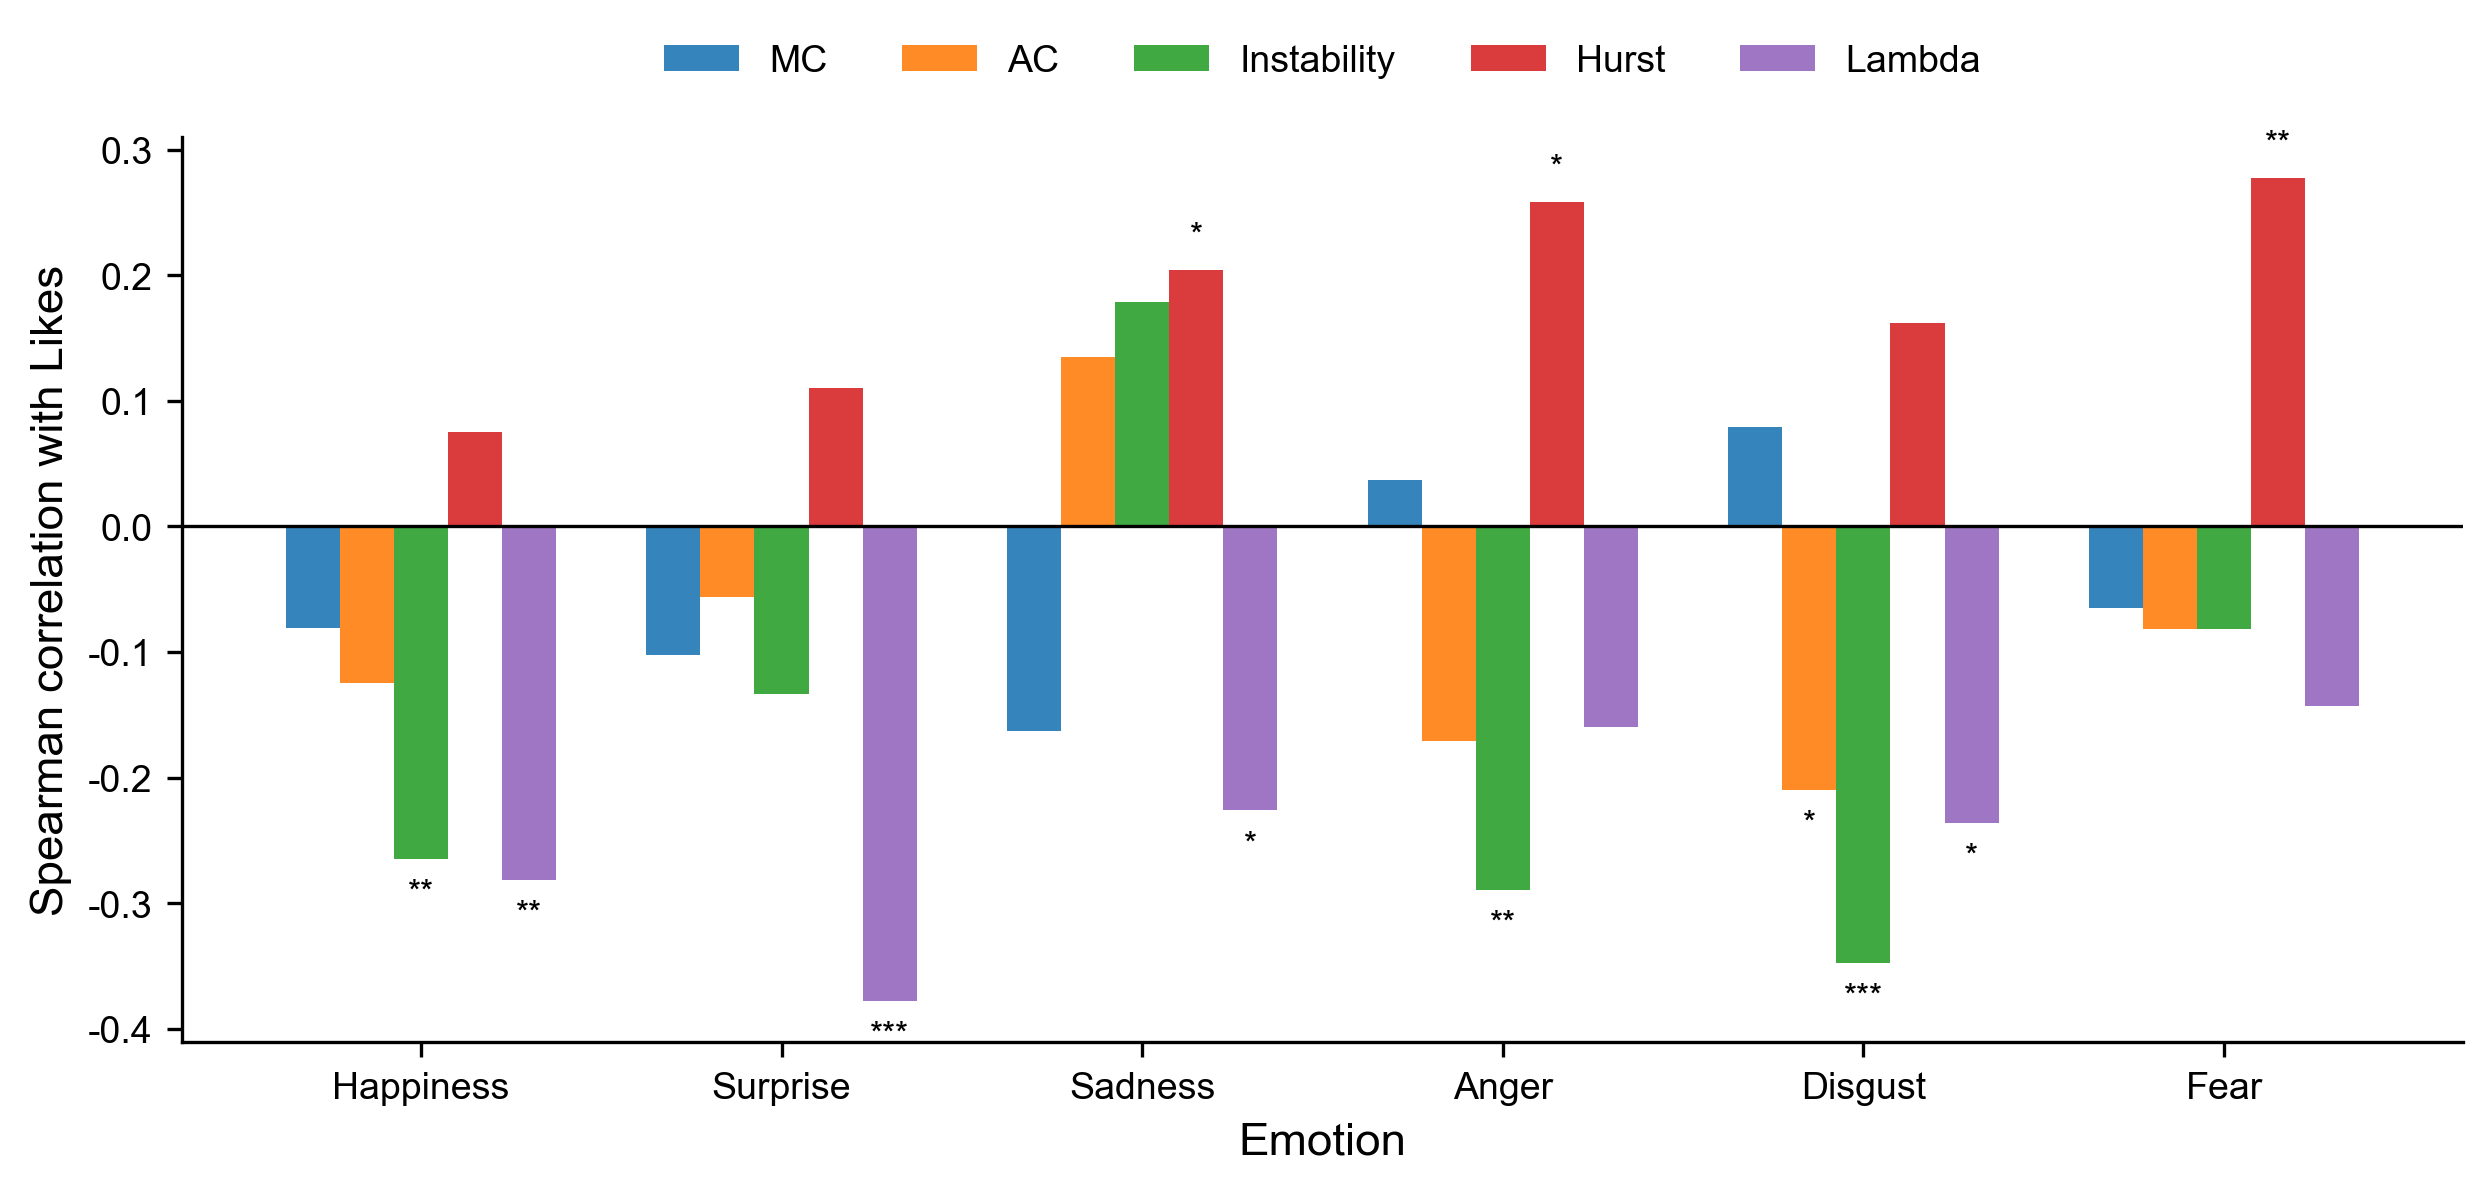

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================================================
# Settings
# ============================================================

metrics = [
    "MC",
    "AC",
    "Instability",
    "Hurst",
    "Lambda"
]

emotions = [
    "Happiness",
    "Surprise",
    "Sadness",
    "Anger",
    "Disgust",
    "Fear"
]

# ============================================================
# Calculate Spearman correlations
# ============================================================

rho_matrix = np.zeros((5, 6))
p_matrix = np.zeros((5, 6))

for i in range(5):
    for j in range(6):

        idx = i * 6 + j

        rho, p = spearmanr(
            X[:, idx],
            y,
            nan_policy="omit"
        )

        rho_matrix[i, j] = rho
        p_matrix[i, j] = p

        print(
            f"{metrics[i]:12s} | {emotions[j]:10s} | "
            f"rho = {rho:.3f}, p = {p:.3e}"
        )


# ============================================================
# Plot grouped bar chart
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax = plt.subplots(
    figsize=(8.5, 4.2),
    dpi=300
)

x = np.arange(len(emotions))

bar_width = 0.15

for i, metric in enumerate(metrics):

    offset = (i - (len(metrics) - 1) / 2) * bar_width

    bars = ax.bar(
        x + offset,
        rho_matrix[i],
        width=bar_width,
        label=metric,
        alpha=0.9
    )

    # significance
    for j, bar in enumerate(bars):

        p = p_matrix[i, j]

        if p < 0.001:
            star = "***"
        elif p < 0.01:
            star = "**"
        elif p < 0.05:
            star = "*"
        else:
            star = ""

        if star:

            value = rho_matrix[i, j]

            y_pos = (
                value + 0.015
                if value >= 0
                else value - 0.015
            )

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y_pos,
                star,
                ha="center",
                va="bottom" if value >= 0 else "top",
                fontsize=8
            )


# ============================================================
# Style
# ============================================================

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(
    emotions,
    fontsize=10
)

ax.set_ylabel(
    "Spearman correlation with Likes",
    fontsize=11
)

ax.set_xlabel(
    "Emotion",
    fontsize=11
)

ax.legend(
    frameon=False,
    ncol=5,
    fontsize=9,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.14)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="both",
    labelsize=9
)

plt.tight_layout()
plt.show()

In [33]:
dy_feature.shape,y.shape

((100, 30), (98,))


Coins
Inertia                  | Happiness  | rho = 0.282, p = 4.967e-03
Inertia                  | Surprise   | rho = 0.378, p = 1.256e-04
Inertia                  | Sadness    | rho = 0.226, p = 2.520e-02
Inertia                  | Anger      | rho = 0.160, p = 1.164e-01
Inertia                  | Disgust    | rho = 0.236, p = 1.942e-02
Inertia                  | Fear       | rho = 0.143, p = 1.612e-01
Instability              | Happiness  | rho = -0.265, p = 8.422e-03
Instability              | Surprise   | rho = -0.133, p = 1.905e-01
Instability              | Sadness    | rho = 0.178, p = 7.873e-02
Instability              | Anger      | rho = -0.289, p = 3.881e-03
Instability              | Disgust    | rho = -0.348, p = 4.533e-04
Instability              | Fear       | rho = -0.082, p = 4.249e-01
Average controllability  | Happiness  | rho = -0.125, p = 2.214e-01
Average controllability  | Surprise   | rho = -0.056, p = 5.849e-01
Average controllability  | Sadness    | rho = 0.

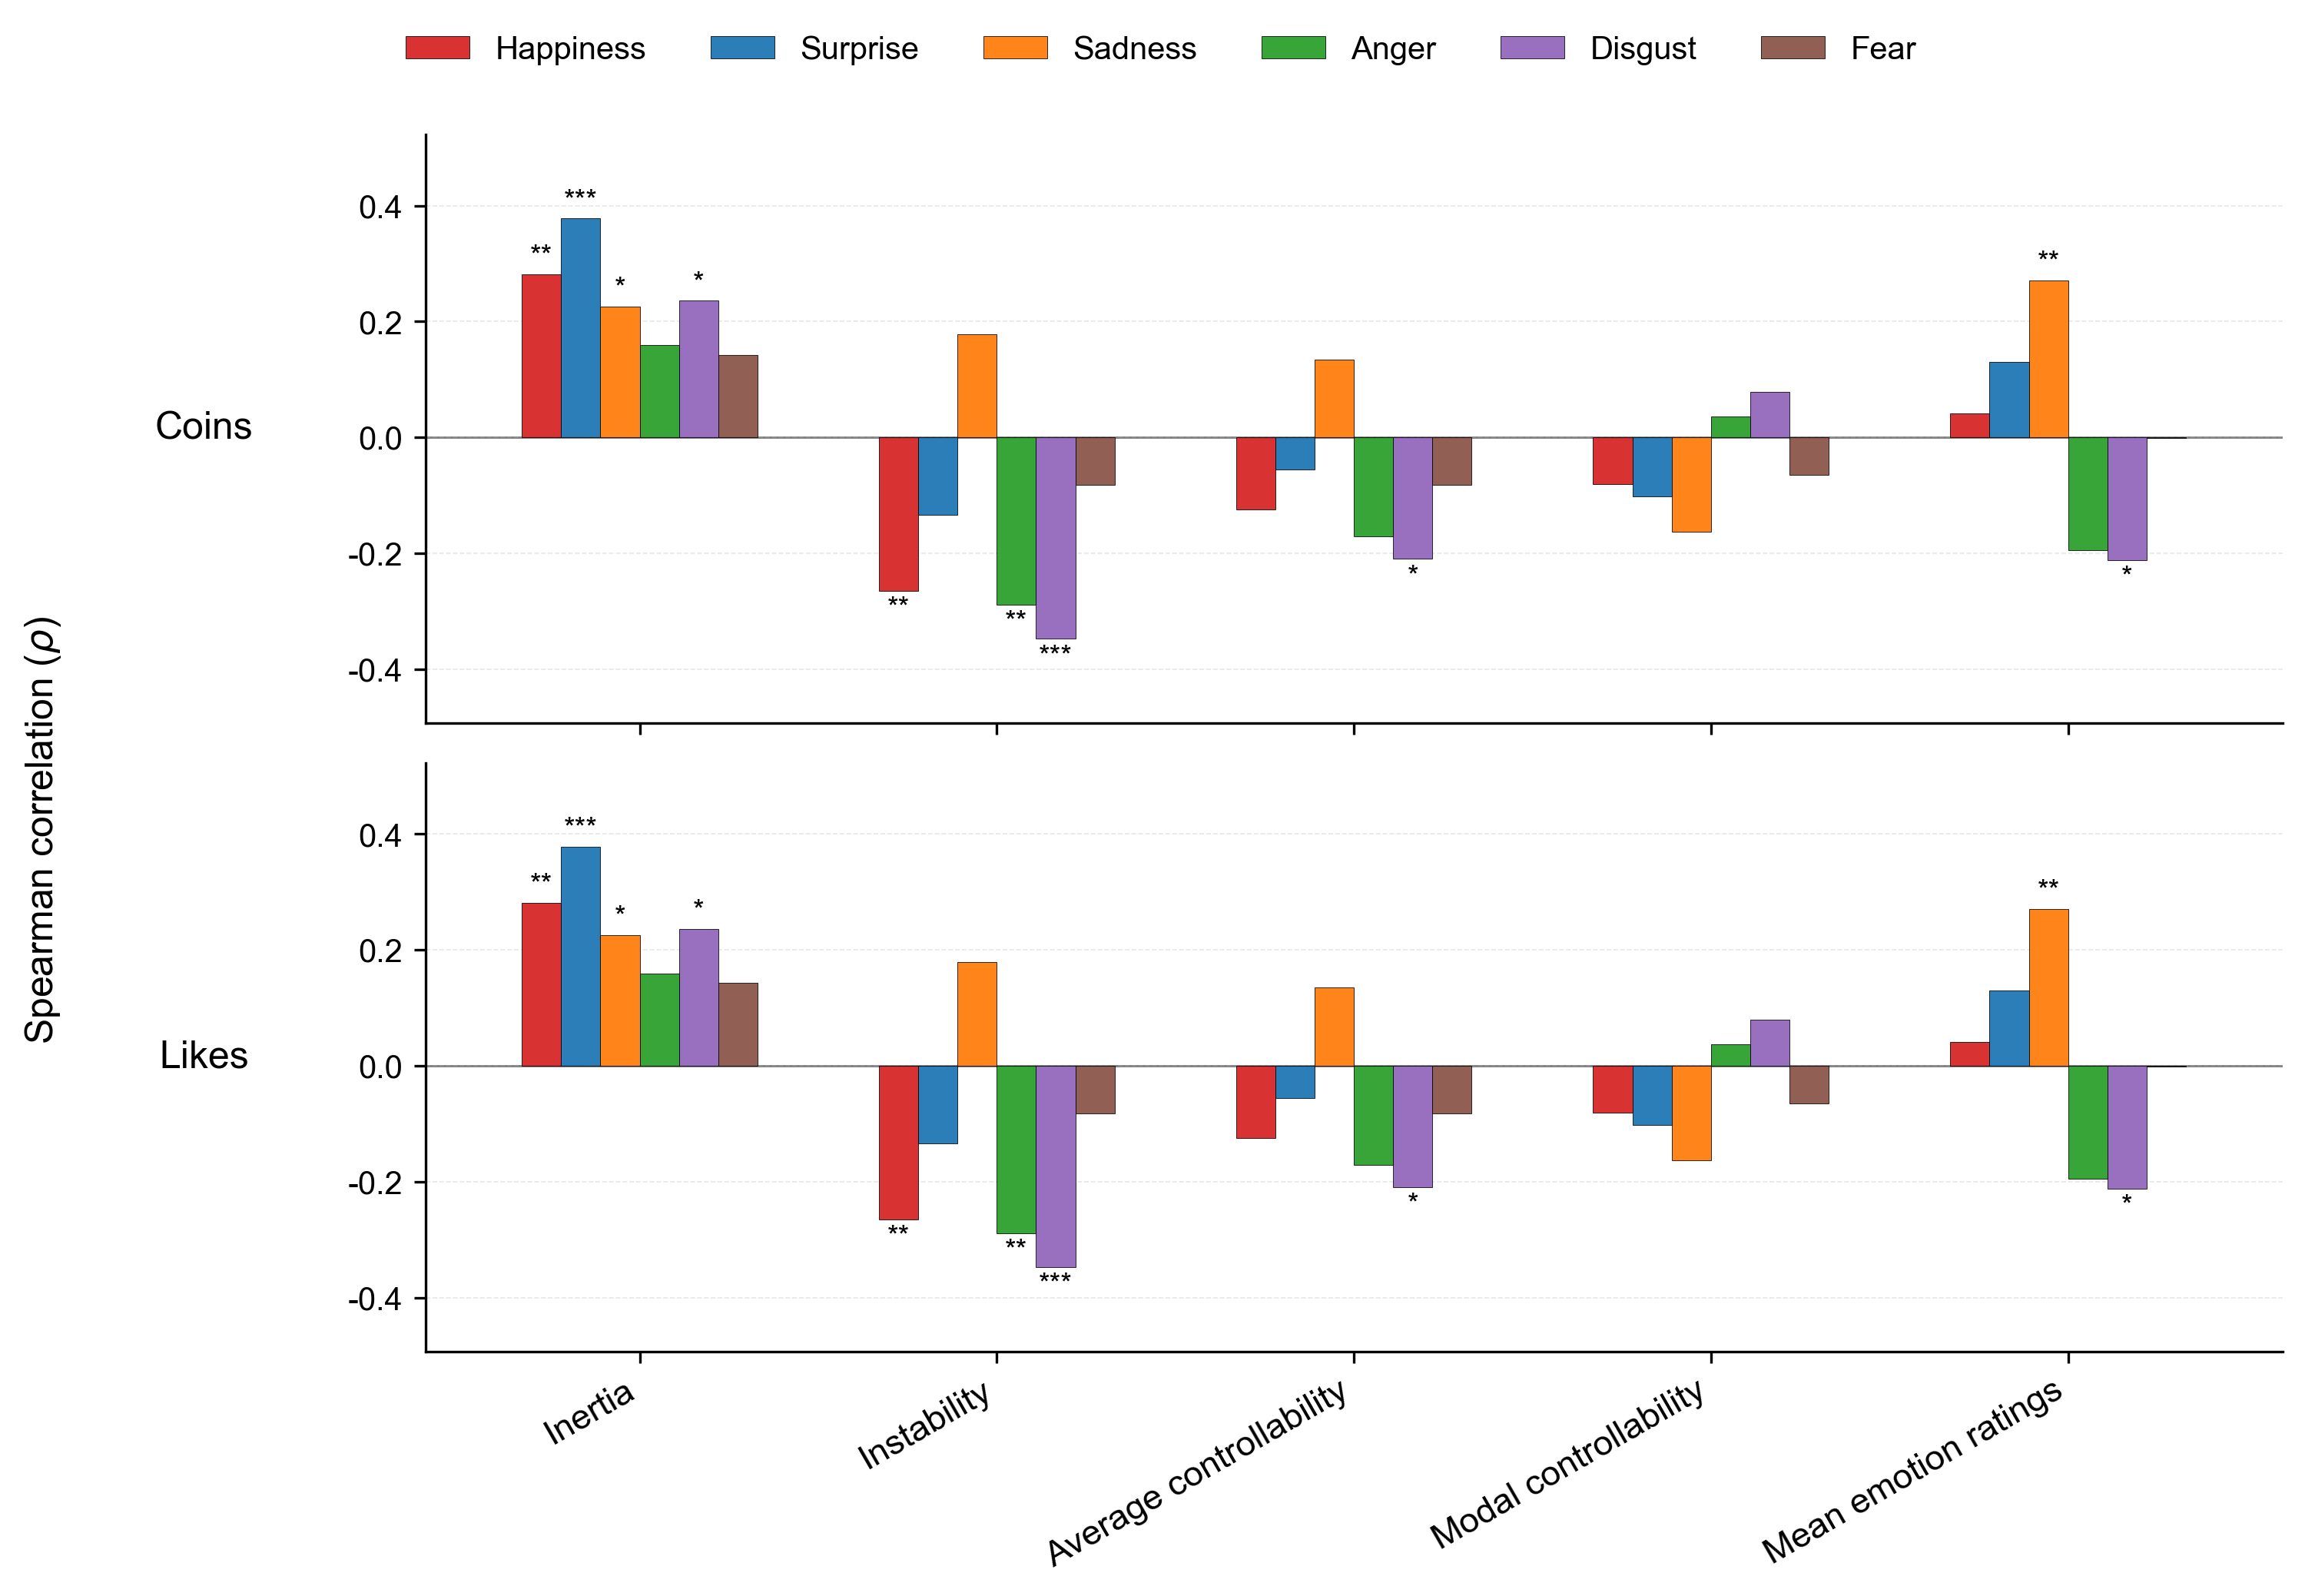

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# ============================================================
# 1. Settings
# ============================================================

emotions = [
    "Happiness",
    "Surprise",
    "Sadness",
    "Anger",
    "Disgust",
    "Fear"
]

feature_names = [
    "Inertia",
    "Instability",
    "Average controllability",
    "Modal controllability",
    "Mean emotion ratings"
]

# dy_feature 原始结构：
# [MC × 6,
#  AC × 6,
#  Instability × 6,
#  Hurst × 6,
#  Lambda × 6]

feature_mapping = [
    4,      # Inertia = Lambda
    2,      # Instability
    1,      # Average controllability = A
    0,      # Modal controllability = MC
    None    # Static features
]

n_features = len(feature_names)
n_emotions = len(emotions)


# ============================================================
# 2. Static features
# ============================================================

static_feature = (
    np.array(curves)[likes == likes]
    .mean(axis=1)[mask_dy]
)


# ============================================================
# 3. Correlation calculation function
# ============================================================

def calculate_correlation_matrix(target_y):

    target_y = np.asarray(target_y)

    X_dynamic = dy_feature[mask_dy]

    assert len(target_y) == X_dynamic.shape[0], (
        f"target_y length = {len(target_y)}, "
        f"but X has {X_dynamic.shape[0]} samples"
    )

    assert static_feature.shape[0] == len(target_y), (
        f"static_feature has {static_feature.shape[0]} samples, "
        f"but target_y has {len(target_y)}"
    )

    rho_matrix = np.full(
        (n_features, n_emotions),
        np.nan
    )

    p_matrix = np.full(
        (n_features, n_emotions),
        np.nan
    )

    # ========================================================
    # Dynamic features
    # ========================================================

    for fi, block_idx in enumerate(feature_mapping):

        if block_idx is None:
            continue

        for ei in range(n_emotions):

            col_idx = block_idx * n_emotions + ei

            rho, p = spearmanr(
                X_dynamic[:, col_idx],
                target_y,
                nan_policy="omit"
            )

            rho_matrix[fi, ei] = rho
            p_matrix[fi, ei] = p

    # ========================================================
    # Inertia = -Lambda
    # ========================================================

    rho_matrix[0] = -rho_matrix[0]

    # ========================================================
    # Static features
    # ========================================================

    for ei in range(n_emotions):

        rho, p = spearmanr(
            static_feature[:, ei],
            target_y,
            nan_policy="omit"
        )

        rho_matrix[4, ei] = rho
        p_matrix[4, ei] = p

    return rho_matrix, p_matrix


# ============================================================
# 4. Calculate Coins and Likes
# ============================================================

rho_coins, p_coins = calculate_correlation_matrix(y_coins[mask_dy])
rho_likes, p_likes = calculate_correlation_matrix(y)


# ============================================================
# 5. Print results
# ============================================================

for target_name, rho_mat, p_mat in [
    ("Coins", rho_coins, p_coins),
    ("Likes", rho_likes, p_likes)
]:

    print("\n" + "=" * 70)
    print(target_name)
    print("=" * 70)

    for fi in range(n_features):

        for ei in range(n_emotions):

            print(
                f"{feature_names[fi]:24s} | "
                f"{emotions[ei]:10s} | "
                f"rho = {rho_mat[fi, ei]:.3f}, "
                f"p = {p_mat[fi, ei]:.3e}"
            )


# ============================================================
# 6. Colors
# ============================================================

emotion_colors = {
    "Happiness": "#D62728",
    "Surprise":  "#1F77B4",
    "Sadness":   "#FF7F0E",
    "Anger":     "#2CA02C",
    "Disgust":   "#9467BD",
    "Fear":      "#8C564B"
}

ecolors = [
    emotion_colors[e]
    for e in emotions
]


# ============================================================
# 7. Plot settings
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 9

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7.0),
    dpi=300,
    sharex=True,
    sharey=True
)

x_centers = np.arange(n_features)

bar_w = 0.11


# ============================================================
# 8. Two panels
# Coins on top, Likes on bottom
# ============================================================

plot_data = [
    ("Coins", rho_coins, p_coins),
    ("Likes", rho_likes, p_likes)
]

for pi, (panel_name, rho_matrix, p_matrix) in enumerate(plot_data):

    ax = axes[pi]

    # ========================================================
    # Six emotions
    # ========================================================

    for ei, emotion in enumerate(emotions):

        offset = (
            ei - (n_emotions - 1) / 2
        ) * bar_w

        bars = ax.bar(
            x_centers + offset,
            rho_matrix[:, ei],
            width=bar_w,
            label=emotion if pi == 0 else None,
            color=ecolors[ei],
            edgecolor="black",
            linewidth=0.2,
            alpha=0.95,
            zorder=3
        )

        # ====================================================
        # Significance
        # ====================================================

        for fi, bar in enumerate(bars):

            value = rho_matrix[fi, ei]
            p = p_matrix[fi, ei]

            if not np.isfinite(value):
                continue

            if p < 0.001:
                star = "***"
            elif p < 0.01:
                star = "**"
            elif p < 0.05:
                star = "*"
            else:
                star = ""

            if star:

                if value >= 0:
                    y_pos = value + 0.008
                    va = "bottom"
                else:
                    y_pos = value - 0.008
                    va = "top"

                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    y_pos,
                    star,
                    ha="center",
                    va=va,
                    fontsize=9
                )

    # ========================================================
    # Zero line
    # ========================================================

    ax.axhline(
        0,
        color="black",
        linewidth=0.7,
        alpha=0.5,
        zorder=1
    )

    # ========================================================
    # Panel label
    # ========================================================

    ax.set_ylabel(
        panel_name,
        rotation=0,
        labelpad=45,
        va="center",
        fontsize=12
    )

    # ========================================================
    # Style
    # ========================================================

    ax.set_xlim(
        -0.6,
        n_features - 0.4
    )

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.4,
        alpha=0.3,
        zorder=0
    )

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=10
    )


# ============================================================
# 9. Same y-axis range for both panels
# ============================================================

all_values = np.concatenate([
    rho_coins[np.isfinite(rho_coins)],
    rho_likes[np.isfinite(rho_likes)]
])

ymin = all_values.min()
ymax = all_values.max()

padding = max(
    0.05,
    (ymax - ymin) * 0.20
)

for ax in axes:
    ax.set_ylim(
        ymin - padding,
        ymax + padding
    )


# ============================================================
# 10. X-axis labels only on bottom panel
# ============================================================

axes[-1].set_xticks(x_centers)

axes[-1].set_xticklabels(
    feature_names,
    fontsize=11,rotation=30,ha="right"
)


# ============================================================
# 11. Shared y-axis meaning
# ============================================================

# 左侧 panel 已经写 Coins / Likes，
# 所以整体 y 含义放成 fig text，避免重复

fig.text(
    0.015,
    0.50,
    r"Spearman correlation ($\rho$)",
    rotation=90,
    va="center",
    ha="center",
    fontsize=12
)


# ============================================================
# 12. Top legend
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    ncol=6,
    loc="upper center",
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.01)
)


# ============================================================
# 13. Layout
# ============================================================

fig.tight_layout(
    rect=[0.05, 0.02, 1, 0.95],
    h_pad=1.0
)


# ============================================================
# 14. Save
# ============================================================

plt.savefig(
    "emotion_feature_correlation_coins_likes.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "emotion_feature_correlation_coins_likes.pdf",
    bbox_inches="tight"
)

plt.show()

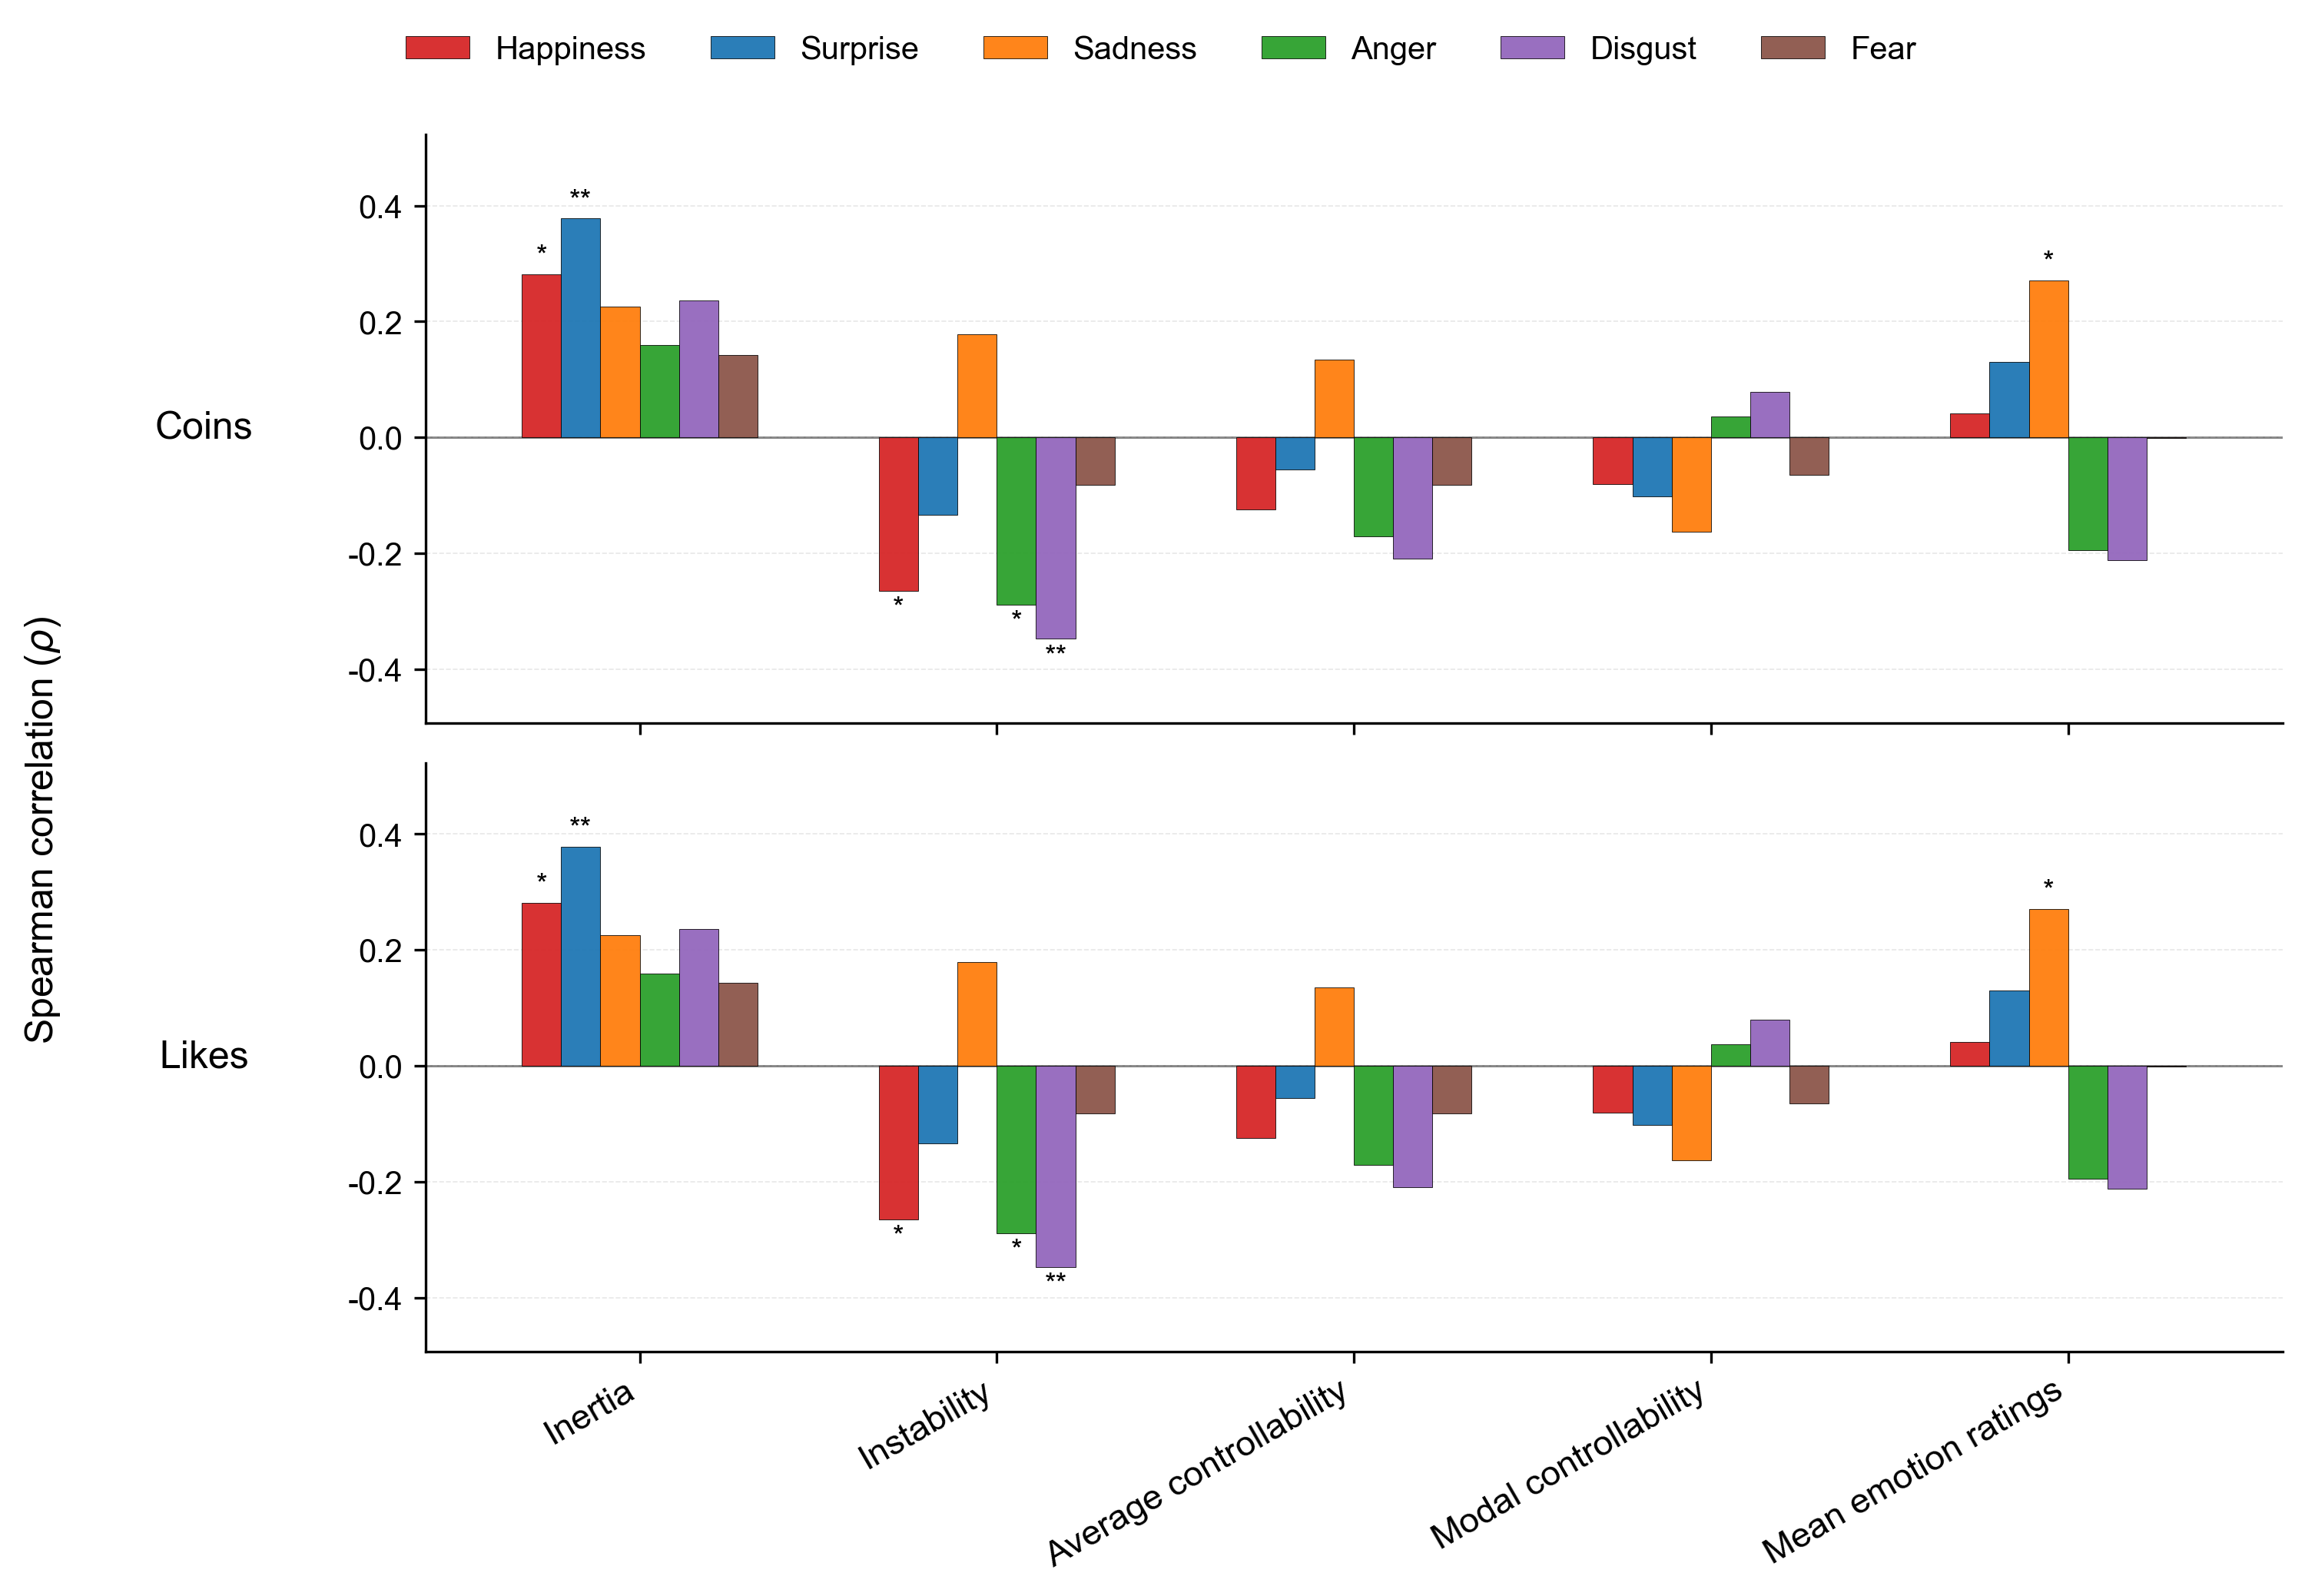

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests


# ============================================================
# 1. Settings
# ============================================================

emotions = [
    "Happiness",
    "Surprise",
    "Sadness",
    "Anger",
    "Disgust",
    "Fear"
]

feature_names = [
    "Inertia",
    "Instability",
    "Average controllability",
    "Modal controllability",
    "Mean emotion ratings"
]

# dy_feature 原始结构：
# [MC × 6,
#  AC × 6,
#  Instability × 6,
#  Hurst × 6,
#  Lambda × 6]

feature_mapping = [
    4,      # Inertia = Lambda
    2,      # Instability
    1,      # Average controllability = AC
    0,      # Modal controllability = MC
    None    # Static features
]

n_features = len(feature_names)
n_emotions = len(emotions)


# ============================================================
# 2. Static features
# ============================================================

static_feature = (
    np.array(curves)[likes == likes]
    .mean(axis=1)[mask_dy]
)


# ============================================================
# 3. Correlation calculation function
# ============================================================

def calculate_correlation_matrix(target_y):

    target_y = np.asarray(target_y)

    X_dynamic = dy_feature[mask_dy]

    assert len(target_y) == X_dynamic.shape[0], (
        f"target_y length = {len(target_y)}, "
        f"but X has {X_dynamic.shape[0]} samples"
    )

    assert static_feature.shape[0] == len(target_y), (
        f"static_feature has {static_feature.shape[0]} samples, "
        f"but target_y has {len(target_y)}"
    )

    rho_matrix = np.full(
        (n_features, n_emotions),
        np.nan
    )

    p_matrix = np.full(
        (n_features, n_emotions),
        np.nan
    )

    # ========================================================
    # Dynamic features
    # ========================================================

    for fi, block_idx in enumerate(feature_mapping):

        if block_idx is None:
            continue

        for ei in range(n_emotions):

            col_idx = block_idx * n_emotions + ei

            rho, p = spearmanr(
                X_dynamic[:, col_idx],
                target_y,
                nan_policy="omit"
            )

            rho_matrix[fi, ei] = rho
            p_matrix[fi, ei] = p

    # ========================================================
    # Inertia = -Lambda
    # ========================================================

    rho_matrix[0] = -rho_matrix[0]

    # ========================================================
    # Static features
    # ========================================================

    for ei in range(n_emotions):

        rho, p = spearmanr(
            static_feature[:, ei],
            target_y,
            nan_policy="omit"
        )

        rho_matrix[4, ei] = rho
        p_matrix[4, ei] = p

    return rho_matrix, p_matrix


# ============================================================
# 4. FDR correction function
# ============================================================

def fdr_correct_matrix(p_matrix, method="fdr_bh"):

    p_flat = np.asarray(p_matrix, dtype=float).flatten()

    q_flat = np.full_like(
        p_flat,
        np.nan,
        dtype=float
    )

    valid = np.isfinite(p_flat)

    if np.any(valid):
        _, q_flat_valid, _, _ = multipletests(
            p_flat[valid],
            alpha=0.05,
            method=method
        )
        q_flat[valid] = q_flat_valid

    q_matrix = q_flat.reshape(p_matrix.shape)

    return q_matrix


# ============================================================
# 5. Calculate Coins and Likes
# ============================================================

rho_coins, p_coins = calculate_correlation_matrix(y_coins[mask_dy])
rho_likes, p_likes = calculate_correlation_matrix(y)

# FDR correction separately for Coins and Likes
q_coins = fdr_correct_matrix(p_coins, method="fdr_bh")
q_likes = fdr_correct_matrix(p_likes, method="fdr_bh")


# ============================================================
# 6. Colors
# ============================================================

emotion_colors = {
    "Happiness": "#D62728",
    "Surprise":  "#1F77B4",
    "Sadness":   "#FF7F0E",
    "Anger":     "#2CA02C",
    "Disgust":   "#9467BD",
    "Fear":      "#8C564B"
}

ecolors = [
    emotion_colors[e]
    for e in emotions
]


# ============================================================
# 7. Plot settings
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 9

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7.0),
    dpi=300,
    sharex=True,
    sharey=True
)

x_centers = np.arange(n_features)
bar_w = 0.11


# ============================================================
# 8. Two panels
# Coins on top, Likes on bottom
# Use q_matrix for significance stars
# ============================================================

plot_data = [
    ("Coins", rho_coins, q_coins),
    ("Likes", rho_likes, q_likes)
]

for pi, (panel_name, rho_matrix, q_matrix) in enumerate(plot_data):

    ax = axes[pi]

    # ========================================================
    # Six emotions
    # ========================================================

    for ei, emotion in enumerate(emotions):

        offset = (
            ei - (n_emotions - 1) / 2
        ) * bar_w

        bars = ax.bar(
            x_centers + offset,
            rho_matrix[:, ei],
            width=bar_w,
            label=emotion if pi == 0 else None,
            color=ecolors[ei],
            edgecolor="black",
            linewidth=0.2,
            alpha=0.95,
            zorder=3
        )

        # ====================================================
        # Significance (FDR-corrected q-values)
        # ====================================================

        for fi, bar in enumerate(bars):

            value = rho_matrix[fi, ei]
            q = q_matrix[fi, ei]

            if not np.isfinite(value) or not np.isfinite(q):
                continue

            if q < 0.001:
                star = "***"
            elif q < 0.01:
                star = "**"
            elif q < 0.05:
                star = "*"
            else:
                star = ""

            if star:

                if value >= 0:
                    y_pos = value + 0.008
                    va = "bottom"
                else:
                    y_pos = value - 0.008
                    va = "top"

                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    y_pos,
                    star,
                    ha="center",
                    va=va,
                    fontsize=9
                )

    # ========================================================
    # Zero line
    # ========================================================

    ax.axhline(
        0,
        color="black",
        linewidth=0.7,
        alpha=0.5,
        zorder=1
    )

    # ========================================================
    # Panel label
    # ========================================================

    ax.set_ylabel(
        panel_name,
        rotation=0,
        labelpad=45,
        va="center",
        fontsize=12
    )

    # ========================================================
    # Style
    # ========================================================

    ax.set_xlim(
        -0.6,
        n_features - 0.4
    )

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.4,
        alpha=0.3,
        zorder=0
    )

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=10
    )


# ============================================================
# 9. Same y-axis range for both panels
# ============================================================

all_values = np.concatenate([
    rho_coins[np.isfinite(rho_coins)],
    rho_likes[np.isfinite(rho_likes)]
])

ymin = all_values.min()
ymax = all_values.max()

padding = max(
    0.05,
    (ymax - ymin) * 0.20
)

for ax in axes:
    ax.set_ylim(
        ymin - padding,
        ymax + padding
    )


# ============================================================
# 10. X-axis labels only on bottom panel
# ============================================================

axes[-1].set_xticks(x_centers)

axes[-1].set_xticklabels(
    feature_names,
    fontsize=11,
    rotation=30,
    ha="right"
)


# ============================================================
# 11. Shared y-axis meaning
# ============================================================

fig.text(
    0.015,
    0.50,
    r"Spearman correlation ($\rho$)",
    rotation=90,
    va="center",
    ha="center",
    fontsize=12
)


# ============================================================
# 12. Top legend
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    ncol=6,
    loc="upper center",
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.01)
)


# ============================================================
# 13. Layout
# ============================================================

fig.tight_layout(
    rect=[0.05, 0.02, 1, 0.95],
    h_pad=1.0
)


# ============================================================
# 14. Save
# ============================================================

plt.savefig(
    "emotion_feature_correlation_coins_likes_fdr.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "emotion_feature_correlation_coins_likes_fdr.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## deep learning

In [37]:
X_valid = X_seq[mask].astype(np.float32)
y_valid = y_01.astype(np.float32)   # 你说这里就用 y_01，不再 mask

print("X_valid shape:", X_valid.shape)
print("y_valid shape:", y_valid.shape)


X_valid shape: (100, 2000, 6)
y_valid shape: (100,)


In [38]:


class MovieCurveDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# =========================
# 2. GRU 回归模型
# =========================

class GRURegressor(nn.Module):
    def __init__(
        self,
        input_dim=6,
        hidden_dim=64,
        num_layers=1,
        dropout=0.2,
        bidirectional=False
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        gru_out_dim = hidden_dim * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.Linear(gru_out_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, T, 6)
        out, h = self.gru(x)

        # 取最后一个时间点的隐藏状态
        last_out = out[:, -1, :]

        y_pred = self.head(last_out)
        return y_pred

In [39]:
class RNNRegressor(nn.Module):
    def __init__(
        self,
        input_dim=6,
        hidden_dim=64,
        num_layers=1,
        dropout=0.2,
        bidirectional=False
    ):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            nonlinearity="tanh",
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        out_dim = hidden_dim * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.Linear(out_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, h = self.rnn(x)
        last_out = out[:, -1, :]
        return self.head(last_out)
class LSTMRegressor(nn.Module):
    def __init__(
        self,
        input_dim=6,
        hidden_dim=64,
        num_layers=1,
        dropout=0.2,
        bidirectional=False
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        out_dim = hidden_dim * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.Linear(out_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, (h, c) = self.lstm(x)
        last_out = out[:, -1, :]
        return self.head(last_out)
class CNNRegressor(nn.Module):
    def __init__(
        self,
        input_dim=6,
        hidden_dim=64,
        dropout=0.2,
        bidirectional=False  # 保留参数接口，不实际使用
    ):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, T, 6)
        x = x.transpose(1, 2)  # -> (batch, 6, T)
        feat = self.conv(x)    # -> (batch, hidden_dim, T)
        feat = self.pool(feat).squeeze(-1)  # -> (batch, hidden_dim)
        return self.head(feat)
class TransformerRegressor(nn.Module):
    def __init__(
        self,
        input_dim=6,
        hidden_dim=64,
        num_layers=2,
        dropout=0.2,
        bidirectional=False,  # 保留参数接口，不实际使用
        nhead=4,
        max_len=2000
    ):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.pos_embedding = nn.Parameter(
            torch.randn(1, max_len, hidden_dim) * 0.02
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, T, 6)
        B, T, D = x.shape

        x = self.input_proj(x)

        if T > self.pos_embedding.shape[1]:
            raise ValueError(
                f"T={T} exceeds max_len={self.pos_embedding.shape[1]}. "
                "Increase max_len in TransformerRegressor."
            )

        x = x + self.pos_embedding[:, :T, :]

        out = self.encoder(x)

        # 用平均池化，比只取最后一个时间点更稳
        feat = out.mean(dim=1)

        return self.head(feat)


In [40]:
def standardize_by_train(X_train, X_test):
    mean = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
    std = X_train.reshape(-1, X_train.shape[-1]).std(axis=0)
    std[std == 0] = 1.0

    X_train_z = (X_train - mean) / std
    X_test_z = (X_test - mean) / std

    return X_train_z.astype(np.float32), X_test_z.astype(np.float32)


def train_one_fold(
    X_train,
    y_train,
    X_test,
    y_test,
    hidden_dim=64,
    num_layers=1,
    dropout=0.2,
    bidirectional=False,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=8,
    max_epochs=300,
    patience=30,
    device=None
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    train_dataset = MovieCurveDataset(X_train, y_train)
    test_dataset = MovieCurveDataset(X_test, y_test)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = GRURegressor(
        input_dim=X_train.shape[-1],
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=bidirectional
    ).to(device)

    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_loss = np.inf
    best_state = None
    wait = 0

    for epoch in range(max_epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_losses.append(loss.item())

        # 用 test fold 做 early stopping
        # 样本少时这样可以先快速探索；正式论文建议再划分 validation
        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                pred = model(xb)
                loss = criterion(pred, yb)
                val_losses.append(loss.item())

        val_loss = np.mean(val_losses)

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()

    preds = []

    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            pred = model(xb)
            preds.append(pred.cpu().numpy())

    y_pred = np.vstack(preds).ravel()

    return y_pred, model

In [41]:
# =========================
# 3. KFold 训练和评估
# =========================

def evaluate_gru_kfold(
    X_valid,
    y_valid,
    n_splits=4,
    random_state=42,
    hidden_dim=64,
    num_layers=1,
    dropout=0.2,
    bidirectional=False,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=8,
    max_epochs=300,
    patience=30
):
    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []
    y_oof = np.zeros_like(y_valid, dtype=np.float32)

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_valid), start=1):
        print(f"\nFold {fold}/{n_splits}")

        X_train = X_valid[train_idx]
        X_test = X_valid[test_idx]
        y_train = y_valid[train_idx]
        y_test = y_valid[test_idx]

        X_train_z, X_test_z = standardize_by_train(X_train, X_test)

        y_pred, _ = train_one_fold(
            X_train_z,
            y_train,
            X_test_z,
            y_test,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=bidirectional,
            lr=lr,
            weight_decay=weight_decay,
            batch_size=batch_size,
            max_epochs=max_epochs,
            patience=patience
        )

        y_oof[test_idx] = y_pred

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred)

        sp, sp_p = spearmanr(y_test, y_pred)
        if np.isnan(sp):
            sp = 0.0

        fold_results.append({
            "fold": fold,
            "r2": r2,
            "mae": mae,
            "rmse": rmse,
            "spearman": sp,
            "spearman_p": sp_p
        })

        print(
            f"R2={r2:.3f}, MAE={mae:.3f}, "
            f"RMSE={rmse:.3f}, Spearman={sp:.3f}"
        )

    result_df = pd.DataFrame(fold_results)

    oof_r2 = r2_score(y_valid, y_oof)
    oof_mae = mean_absolute_error(y_valid, y_oof)
    oof_rmse = mean_squared_error(y_valid, y_oof)
    oof_sp, oof_sp_p = spearmanr(y_valid, y_oof)

    if np.isnan(oof_sp):
        oof_sp = 0.0

    summary = {
        "model": "GRU",
        "fold_R2_mean": result_df["r2"].mean(),
        "fold_R2_std": result_df["r2"].std(),
        "fold_MAE_mean": result_df["mae"].mean(),
        "fold_RMSE_mean": result_df["rmse"].mean(),
        "fold_spearman_mean": result_df["spearman"].mean(),
        "fold_spearman_std": result_df["spearman"].std(),
        "oof_R2": oof_r2,
        "oof_MAE": oof_mae,
        "oof_RMSE": oof_rmse,
        "oof_spearman": oof_sp,
        "oof_spearman_p": oof_sp_p
    }

    return result_df, summary, y_oof

In [42]:
# torch.manual_seed(42)
# np.random.seed(42)

# fold_df, summary, y_pred_oof = evaluate_gru_kfold(
#     X_valid,
#     y_valid,
#     n_splits=5,
#     random_state=42,
#     hidden_dim=64,
#     num_layers=1,
#     dropout=0.3,
#     bidirectional=False,
#     lr=1e-3,
#     weight_decay=1e-4,
#     batch_size=8,
#     max_epochs=300,
#     patience=30
# )

# print("\nFold results:")
# print(fold_df)

# print("\nSummary:")
# print(pd.DataFrame([summary]))

In [43]:
def evaluate_deep_model_kfold(
    model_name,
    model_class,
    X_valid,
    y_valid,
    model_kwargs=None,
    n_splits=4,
    random_state=42,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=8,
    max_epochs=300,
    patience=30
):
    X_valid = X_valid.astype(np.float32)
    y_valid = y_valid.astype(np.float32)

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []
    y_oof = np.zeros_like(y_valid, dtype=np.float32)

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_valid), start=1):
        print(f"{model_name} | Fold {fold}/{n_splits}")

        X_train = X_valid[train_idx]
        X_test = X_valid[test_idx]
        y_train = y_valid[train_idx]
        y_test = y_valid[test_idx]

        X_train_z, X_test_z = standardize_by_train(X_train, X_test)

        y_pred, _ = train_one_fold(
            model_class=model_class,
            X_train=X_train_z,
            y_train=y_train,
            X_test=X_test_z,
            y_test=y_test,
            model_kwargs=model_kwargs,
            lr=lr,
            weight_decay=weight_decay,
            batch_size=batch_size,
            max_epochs=max_epochs,
            patience=patience
        )

        y_oof[test_idx] = y_pred

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        sp, sp_p = spearmanr(y_test, y_pred)
        if np.isnan(sp):
            sp = 0.0

        fold_results.append({
            "model": model_name,
            "fold": fold,
            "r2": r2,
            "mae": mae,
            "rmse": rmse,
            "spearman": sp,
            "spearman_p": sp_p
        })

    fold_df = pd.DataFrame(fold_results)

    oof_r2 = r2_score(y_valid, y_oof)
    oof_mae = mean_absolute_error(y_valid, y_oof)
    oof_rmse = np.sqrt(mean_squared_error(y_valid, y_oof))

    oof_sp, oof_sp_p = spearmanr(y_valid, y_oof)
    if np.isnan(oof_sp):
        oof_sp = 0.0

    summary = {
        "model": model_name,
        "fold_R2_mean": fold_df["r2"].mean(),
        "fold_R2_std": fold_df["r2"].std(),
        "fold_MAE_mean": fold_df["mae"].mean(),
        "fold_RMSE_mean": fold_df["rmse"].mean(),
        "fold_spearman_mean": fold_df["spearman"].mean(),
        "fold_spearman_std": fold_df["spearman"].std(),
        "oof_R2": oof_r2,
        "oof_MAE": oof_mae,
        "oof_RMSE": oof_rmse,
        "oof_spearman": oof_sp,
        "oof_spearman_p": oof_sp_p
    }

    return fold_df, summary, y_oof

In [44]:
def train_one_fold(
    model_class,
    X_train,
    y_train,
    X_test,
    y_test,
    model_kwargs=None,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=8,
    max_epochs=300,
    patience=30,
    device=None
):
    if model_kwargs is None:
        model_kwargs = {}

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    train_dataset = MovieCurveDataset(X_train, y_train)
    test_dataset = MovieCurveDataset(X_test, y_test)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = model_class(
        input_dim=X_train.shape[-1],
        **model_kwargs
    ).to(device)

    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_loss = np.inf
    best_state = None
    wait = 0

    for epoch in range(max_epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                pred = model(xb)
                loss = criterion(pred, yb)
                val_losses.append(loss.item())

        val_loss = np.mean(val_losses)

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()

    preds = []

    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            pred = model(xb)
            preds.append(pred.cpu().numpy())

    y_pred = np.vstack(preds).ravel()

    return y_pred, model

In [45]:
torch.manual_seed(42)
np.random.seed(42)

model_configs = {
    "RNN": {
        "class": RNNRegressor,
        "kwargs": {
            "hidden_dim": 64,
            "num_layers": 1,
            "dropout": 0.3,
            "bidirectional": False
        }
    },

}


all_fold_results = []
all_summaries = []
all_oof_preds = {}

for model_name, cfg in model_configs.items():
    print("\n==============================")
    print("Running:", model_name)
    print("==============================")

    fold_df, summary, y_oof = evaluate_deep_model_kfold(
        model_name=model_name,
        model_class=cfg["class"],
        X_valid=X_valid,
        y_valid=y_valid,
        model_kwargs=cfg["kwargs"],
        n_splits=5,
        random_state=42,
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=8,
        max_epochs=300,
        patience=30
    )

    all_fold_results.append(fold_df)
    all_summaries.append(summary)
    all_oof_preds[model_name] = y_oof


fold_results_df = pd.concat(all_fold_results, axis=0, ignore_index=True)
summary_df = pd.DataFrame(all_summaries)

summary_df = summary_df.sort_values("oof_spearman", ascending=False)

print("\nSummary:")
print(summary_df)


Running: RNN
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5

Summary:
  model  fold_R2_mean  fold_R2_std  fold_MAE_mean  fold_RMSE_mean  \
0   RNN      0.234031     0.198985        0.12813        0.159848   

   fold_spearman_mean  fold_spearman_std    oof_R2  oof_MAE  oof_RMSE  \
0            0.519398           0.157183  0.243302  0.12813  0.161836   

   oof_spearman  oof_spearman_p  
0      0.543726    5.035280e-09  


In [46]:
r_list[0] = summary_df.loc[summary_df["model"] == "RNN", "oof_spearman"].values[0]
r2_list[0] = summary_df.loc[summary_df["model"] == "RNN", "oof_R2"].values[0]
p_list[0] = summary_df.loc[summary_df["model"] == "RNN", "oof_spearman_p"].values[0]

In [47]:
import numpy as np
import torch
import random


# ============================================================
# 1. Observed RNN performance
# ============================================================

rho_obs = summary_df.loc[
    summary_df["model"] == "RNN",
    "oof_spearman"
].values[0]

r2_obs = summary_df.loc[
    summary_df["model"] == "RNN",
    "oof_R2"
].values[0]

print("Observed RNN Spearman rho:", rho_obs)
print("Observed RNN R2:", r2_obs)


# ============================================================
# 2. Permutation test
# ============================================================

N_PERM = 1000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

perm_rhos = np.zeros(N_PERM)


for p in range(N_PERM):

    # --------------------------------------------------------
    # Shuffle y labels
    # --------------------------------------------------------

    y_perm = rng.permutation(y_valid)

    # --------------------------------------------------------
    # Fix random seed
    # 保证每次 permutation 的模型初始化/训练随机性一致
    # --------------------------------------------------------

    seed = RANDOM_STATE

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # --------------------------------------------------------
    # Complete 5-fold CV using permuted labels
    # --------------------------------------------------------

    perm_fold_df, perm_summary, perm_y_oof = evaluate_deep_model_kfold(
        model_name="RNN",
        model_class=RNNRegressor,
        X_valid=X_valid,
        y_valid=y_perm,
        model_kwargs={
            "hidden_dim": 64,
            "num_layers": 1,
            "dropout": 0.3,
            "bidirectional": False
        },
        n_splits=5,
        random_state=42,
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=8,
        max_epochs=300,
        patience=30
    )

    # --------------------------------------------------------
    # Save permutation OOF Spearman rho
    # --------------------------------------------------------

    perm_rhos[p] = perm_summary["oof_spearman"]

    # if (p + 1) % 10 == 0:
    #     print(
    #         f"Permutation {p + 1:4d}/{N_PERM} | "
    #         f"rho = {perm_rhos[p]:.4f}"
    #     )


# ============================================================
# 3. One-sided permutation p-value
#
# H0: prediction is no better than random labels
# H1: observed rho > permutation rho
# ============================================================

perm_p = (
    np.sum(perm_rhos >= rho_obs) + 1
) / (
    N_PERM + 1
)


# ============================================================
# 4. Results
# ============================================================

print("\n======================================")
print("Observed rho          :", rho_obs)
print("Observed R2           :", r2_obs)
print("Permutation mean rho  :", perm_rhos.mean())
print("Permutation std rho   :", perm_rhos.std())
print("Permutation max rho   :", perm_rhos.max())
print("Permutation p-value   :", perm_p)
print("======================================")

Observed RNN Spearman rho: 0.5437263726372638
Observed RNN R2: 0.24330157041549683
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RNN | Fold 2/5
RNN | Fold 3/5
RNN | Fold 4/5
RNN | Fold 5/5
RNN | Fold 1/5
RN

In [48]:
r_list[0] = rho_obs
r2_list[0] = r2_obs

# 注意：这里改成 permutation p-value
p_list[0] = perm_p

# 保存完整的 1000 个 permutation rho
perm_rho_list[0] = perm_rhos.copy()

/tmp/ipykernel_1178764/2752953929.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


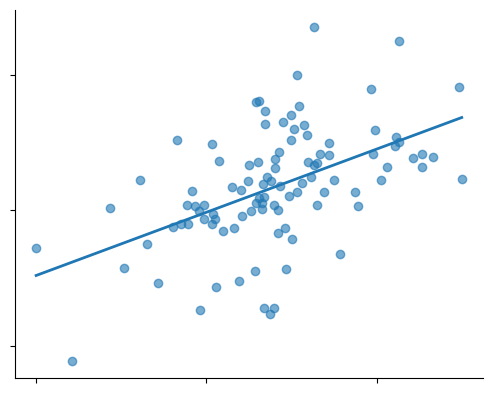

In [49]:
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import MaxNLocator

x = np.asarray(y_valid).reshape(-1, 1)
y = np.asarray(all_oof_preds["RNN"])

reg = LinearRegression()
reg.fit(x, y)

x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
y_line = reg.predict(x_line)

r2 = reg.score(x, y)

fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(y_valid, all_oof_preds["RNN"], alpha=0.6)

ax.plot(
    x_line.ravel(),
    y_line,
    linewidth=2,
    #label=f"Linear fit, $R^2$ = {r2:.3f}"
)

# ax.set_xlabel("Real Values")
# ax.set_ylabel("Predicted Values")
# ax.set_title('Use RNN Predictions')
# 去掉上边框和右边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xticklabels([])
ax.set_yticklabels([])
# 每个坐标轴最多保留 3 个刻度
ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
#ax.set_title('Movie Likes Prediction from Emotional Dynamics')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [50]:
spearmanr(y_valid, all_oof_preds["RNN"]),f"Linear fit, $R^2$ = {r2:.3f}"

(SignificanceResult(statistic=0.5437263726372638, pvalue=5.035280024121015e-09),
 'Linear fit, $R^2$ = 0.257')

In [51]:
# import numpy as np
# import pandas as pd

# from scipy.stats import spearmanr

# from sklearn.model_selection import KFold, cross_validate, cross_val_predict
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA

# from sklearn.svm import SVR
# from sklearn.linear_model import Ridge, BayesianRidge, ElasticNet, Lasso
# from sklearn.ensemble import (
#     RandomForestRegressor,
#     ExtraTreesRegressor,
#     GradientBoostingRegressor,
#     HistGradientBoostingRegressor
# )
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.cross_decomposition import PLSRegression
# from sklearn.dummy import DummyRegressor
# from sklearn.metrics import make_scorer


# # =========================
# # 0. 自定义 Spearman scorer
# # =========================

# def spearman_scorer_func(y_true, y_pred):
#     """
#     返回 y_true 和 y_pred 的 Spearman 相关系数。
#     如果预测值是常数，spearmanr 会返回 nan，这里转成 0。
#     """
#     y_true = np.asarray(y_true).ravel()
#     y_pred = np.asarray(y_pred).ravel()

#     corr, _ = spearmanr(y_true, y_pred)

#     if np.isnan(corr):
#         return 0.0

#     return corr


# spearman_scorer = make_scorer(
#     spearman_scorer_func,
#     greater_is_better=True
# )


# # =========================
# # 1. 过滤有效样本
# # =========================

# mask = (likes == likes)   # 等价于 ~np.isnan(likes)
# X_valid = np.array(curves).reshape(len(curves), -1)[mask, ]
# y_valid = y_01

# print("X_valid shape:", X_valid.shape)
# print("y_valid shape:", y_valid.shape)


# # =========================
# # 2. 定义交叉验证
# # =========================

# cv = KFold(
#     n_splits=4,
#     shuffle=True,
#     random_state=42
# )


# # =========================
# # 3. 定义多个模型
# # =========================

# models = {
#     "Dummy_mean": DummyRegressor(strategy="mean"),

#     "Ridge": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", Ridge(alpha=1.0))
#     ]),

#     "BayesianRidge": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", BayesianRidge())
#     ]),

#     "ElasticNet": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", ElasticNet(
#             alpha=0.01,
#             l1_ratio=0.5,
#             max_iter=10000,
#             random_state=42
#         ))
#     ]),

#     "Lasso": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", Lasso(
#             alpha=0.001,
#             max_iter=10000,
#             random_state=42
#         ))
#     ]),

#     "PLSRegression": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", PLSRegression(
#             n_components=min(10, X_valid.shape[0] - 1, X_valid.shape[1])
#         ))
#     ]),

#     "KNN": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", KNeighborsRegressor(
#             n_neighbors=5,
#             weights="distance"
#         ))
#     ]),

#     "SVR_rbf": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", SVR(
#             kernel="rbf",
#             C=1.0,
#             epsilon=0.1,
#             gamma="scale"
#         ))
#     ]),

#     "RandomForest": RandomForestRegressor(
#         n_estimators=500,
#         max_depth=None,
#         min_samples_leaf=2,
#         random_state=42,
#         n_jobs=-1
#     ),

#     "ExtraTrees": ExtraTreesRegressor(
#         n_estimators=500,
#         max_depth=None,
#         min_samples_leaf=2,
#         random_state=42,
#         n_jobs=-1
#     ),

#     "GradientBoosting": GradientBoostingRegressor(
#         n_estimators=300,
#         learning_rate=0.03,
#         max_depth=2,
#         random_state=42
#     ),

#     "HistGradientBoosting": HistGradientBoostingRegressor(
#         max_iter=300,
#         learning_rate=0.03,
#         l2_regularization=0.1,
#         random_state=42
#     )
# }


# # =========================
# # 4. 循环交叉验证
# # =========================

# results = []

# for name, model in models.items():

#     scores = cross_validate(
#         model,
#         X_valid,
#         y_valid,
#         cv=cv,
#         scoring={
#             "r2": "r2",
#             "mae": "neg_mean_absolute_error",
#             "rmse": "neg_root_mean_squared_error",
#             "spearman": spearman_scorer
#         },
#         return_train_score=True,
#         error_score=np.nan
#     )

#     # 计算 out-of-fold 预测
#     y_pred_oof = cross_val_predict(
#         model,
#         X_valid,
#         y_valid,
#         cv=cv,
#         n_jobs=None
#     )

#     # 整体 OOF Spearman
#     oof_spearman, oof_p = spearmanr(y_valid, y_pred_oof)

#     if np.isnan(oof_spearman):
#         oof_spearman = 0.0
#         oof_p = np.nan

#     results.append({
#         "model": name,

#         "train_R2_mean": np.nanmean(scores["train_r2"]),
#         "test_R2_mean": np.nanmean(scores["test_r2"]),
#         "test_R2_std": np.nanstd(scores["test_r2"]),

#         "test_MAE_mean": -np.nanmean(scores["test_mae"]),
#         "test_RMSE_mean": -np.nanmean(scores["test_rmse"]),

#         "test_spearman_mean": np.nanmean(scores["test_spearman"]),
#         "test_spearman_std": np.nanstd(scores["test_spearman"]),

#         "oof_spearman": oof_spearman,
#         "oof_spearman_p": oof_p
#     })


# result_df = pd.DataFrame(results)

# # 如果你更关心趋势，就按 oof_spearman 排序
# result_df = result_df.sort_values("oof_spearman", ascending=False)

# print(result_df)

In [52]:
# import numpy as np
# import pandas as pd

# from sklearn.model_selection import KFold, cross_validate
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA

# from sklearn.svm import SVR
# from sklearn.linear_model import Ridge, BayesianRidge, ElasticNet, Lasso
# from sklearn.ensemble import (
#     RandomForestRegressor,
#     ExtraTreesRegressor,
#     GradientBoostingRegressor,
#     HistGradientBoostingRegressor
# )
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.cross_decomposition import PLSRegression
# from sklearn.dummy import DummyRegressor


# # =========================
# # 1. 过滤有效样本
# # =========================

# mask = (likes == likes)   # 等价于 ~np.isnan(likes)

# X_valid = X[mask,:600]
# y_valid = y_01
# print("X_valid shape:", X_valid.shape)
# print("y_valid shape:", y_valid.shape)


# # =========================
# # 2. 定义交叉验证
# # =========================

# cv = KFold(
#     n_splits=4,
#     shuffle=True,
#     random_state=42
# )


# # =========================
# # 3. 定义多个模型
# # =========================

# models = {
#     "Dummy_mean": DummyRegressor(strategy="mean"),

#     "Ridge": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", Ridge(alpha=1.0))
#     ]),

#     "BayesianRidge": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", BayesianRidge())
#     ]),

#     "ElasticNet": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", ElasticNet(
#             alpha=0.01,
#             l1_ratio=0.5,
#             max_iter=10000,
#             random_state=42
#         ))
#     ]),

#     "Lasso": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", Lasso(
#             alpha=0.001,
#             max_iter=10000,
#             random_state=42
#         ))
#     ]),

#     "PLSRegression": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", PLSRegression(
#             n_components=min(10, X_valid.shape[0] - 1, X_valid.shape[1])
#         ))
#     ]),

#     "KNN": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", KNeighborsRegressor(
#             n_neighbors=5,
#             weights="distance"
#         ))
#     ]),

#     "SVR_rbf": Pipeline([
#         ("scaler", StandardScaler()),
#         ("model", SVR(
#             kernel="rbf",
#             C=1.0,
#             epsilon=0.1,
#             gamma="scale"
#         ))
#     ]),

#     "RandomForest": RandomForestRegressor(
#         n_estimators=500,
#         max_depth=None,
#         min_samples_leaf=2,
#         random_state=42,
#         n_jobs=-1
#     ),

#     "ExtraTrees": ExtraTreesRegressor(
#         n_estimators=500,
#         max_depth=None,
#         min_samples_leaf=2,
#         random_state=42,
#         n_jobs=-1
#     ),

#     "GradientBoosting": GradientBoostingRegressor(
#         n_estimators=300,
#         learning_rate=0.03,
#         max_depth=2,
#         random_state=42
#     ),

#     "HistGradientBoosting": HistGradientBoostingRegressor(
#         max_iter=300,
#         learning_rate=0.03,
#         l2_regularization=0.1,
#         random_state=42
#     )
# }


# # =========================
# # 4. 循环交叉验证
# # =========================

# results = []

# for name, model in models.items():
#     scores = cross_validate(
#         model,
#         X_valid,
#         y_valid,
#         cv=cv,
#         scoring={
#             "r2": "r2",
#             "mae": "neg_mean_absolute_error",
#             "rmse": "neg_root_mean_squared_error"
#         },
#         return_train_score=True,
#         error_score=np.nan
#     )

#     results.append({
#         "model": name,
#         "train_R2_mean": np.nanmean(scores["train_r2"]),
#         "test_R2_mean": np.nanmean(scores["test_r2"]),
#         "test_R2_std": np.nanstd(scores["test_r2"]),
#         "test_MAE_mean": -np.nanmean(scores["test_mae"]),
#         "test_RMSE_mean": -np.nanmean(scores["test_rmse"])
#     })

# result_df = pd.DataFrame(results)
# result_df = result_df.sort_values("test_R2_mean", ascending=False)

# print(result_df)

## plt

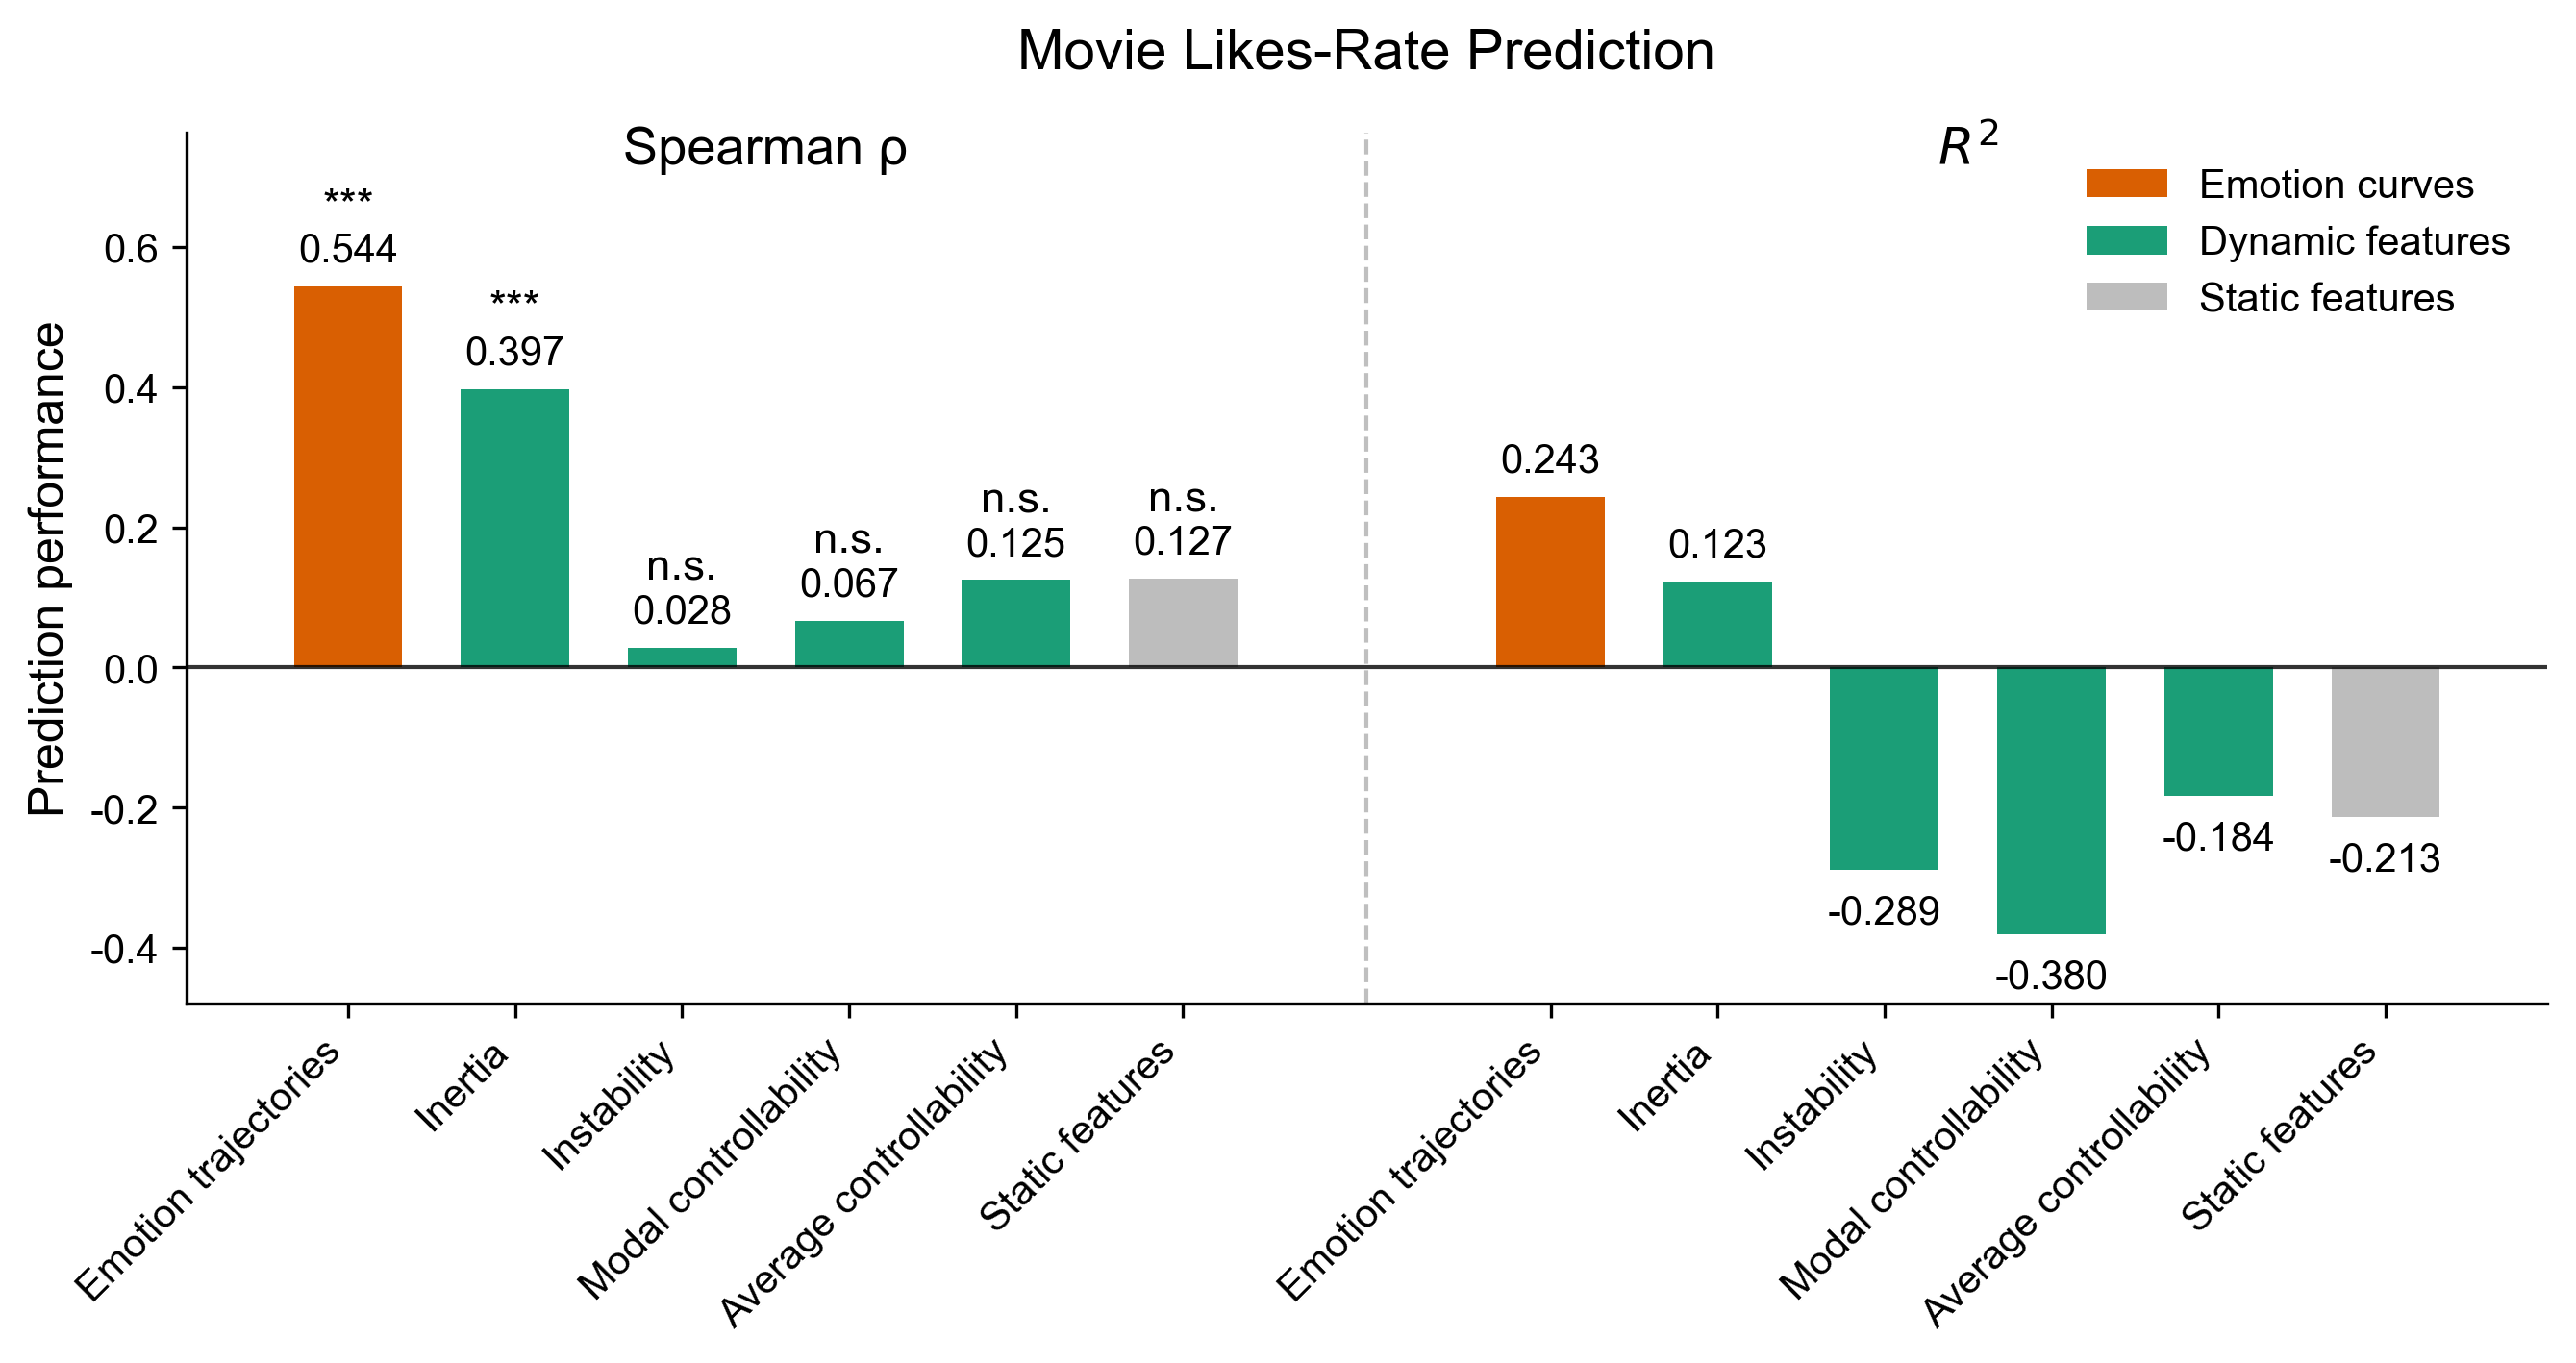

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================
# 1. 数据
# =========================
methods = [
    "Emotion trajectories",
    "Inertia",
    "Instability",
    "Modal controllability",
    "Average controllability",
    "Static features"
]

pearson_r = np.array(r_list)
r_squared = np.array(r2_list)
p_values = np.array(p_list)

# =========================
# 2. 显著性函数
# =========================
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

sig_labels = [p_to_star(p) for p in p_values]

# =========================
# 3. 颜色：按特征类别编码
# =========================
color_emotion = "#D95F02"   # 情绪曲线：突出
color_dynamic = "#1B9E77"   # 动态特征：同一类
color_static  = "#BDBDBD"   # 静态特征：低对比度 baseline

bar_colors = [
    color_emotion,  # Emotion curves
    color_dynamic,  # Inertia
    color_dynamic,  # Instability
    color_dynamic,  # Modal controllability
    color_dynamic,  # Average controllability
    color_static    # Static features
]

# =========================
# 4. 设置横坐标
# =========================
x_left = np.arange(len(methods))
gap = 1.2
x_right = x_left + len(methods) + gap

fig, ax = plt.subplots(figsize=(9, 4.8), dpi=300)

bar_width = 0.65

# =========================
# 5. 画柱状图
# 左右两边使用同一套颜色
# =========================
bars_r = ax.bar(
    x_left,
    pearson_r,
    width=bar_width,
    color=bar_colors
)

bars_r2 = ax.bar(
    x_right,
    r_squared,
    width=bar_width,
    color=bar_colors
)

# =========================
# 6. y=0 基线
# =========================
ax.axhline(
    y=0,
    color="black",
    linewidth=1.0,
    alpha=0.8
)

# =========================
# 7. 添加数值标签
# =========================
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()

        if height >= 0:
            y_text = height + 0.025
            va = "bottom"
        else:
            y_text = height - 0.035
            va = "top"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_text,
            f"{height:.3f}",
            ha="center",
            va=va,
            fontsize=10
        )

add_value_labels(bars_r)
add_value_labels(bars_r2)

# =========================
# 8. 只给 Spearman r 添加显著性标注
# =========================
for bar, star in zip(bars_r, sig_labels):
    height = bar.get_height()

    if height >= 0:
        y_star = height + 0.085
        va = "bottom"
    else:
        y_star = height - 0.085
        va = "top"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_star,
        star,
        ha="center",
        va=va,
        fontsize=11
    )

# =========================
# 9. x 轴标签
# =========================
xticks = np.concatenate([x_left, x_right])
xticklabels = methods + methods

ax.set_xticks(xticks)
ax.set_xticklabels(
    xticklabels,
    rotation=45,
    ha="right",
    fontsize=10
)

# =========================
# 10. 左右两部分标题
# =========================
all_values = np.concatenate([pearson_r, r_squared])
y_max = np.nanmax(all_values)
y_min = np.nanmin(all_values)

y_top = y_max + 0.16

ax.text(
    np.mean(x_left),
    y_top,
    "Spearman ρ",
    ha="center",
    va="bottom",
    fontsize=13
)

ax.text(
    np.mean(x_right),
    y_top,
    r"$R^2$",
    ha="center",
    va="bottom",
    fontsize=13
)

# 中间分隔线
separator_x = (x_left[-1] + x_right[0]) / 2
ax.axvline(
    separator_x,
    linestyle="--",
    linewidth=1,
    color="gray",
    alpha=0.5
)

# =========================
# 11. 图例
# =========================
legend_handles = [
    Patch(facecolor=color_emotion, label="Emotion curves"),
    Patch(facecolor=color_dynamic, label="Dynamic features"),
    Patch(facecolor=color_static, label="Static features")
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    fontsize=10,
    loc="upper right"
)

# =========================
# 12. 坐标轴与标题
# =========================
ax.set_ylabel("Prediction performance", fontsize=12)

ax.set_title(
    "Movie Likes-Rate Prediction",
    fontsize=14,
    pad=16
)

padding_top = 0.22
padding_bottom = 0.10

ax.set_ylim(
    y_min - padding_bottom,
    y_max + padding_top
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()

# =========================
# 13. 保存图片
# =========================
plt.savefig("movie_likes_prediction_barplot.svg", dpi=300, bbox_inches="tight")
plt.savefig("movie_likes_prediction_barplot.pdf", bbox_inches="tight")

plt.show()

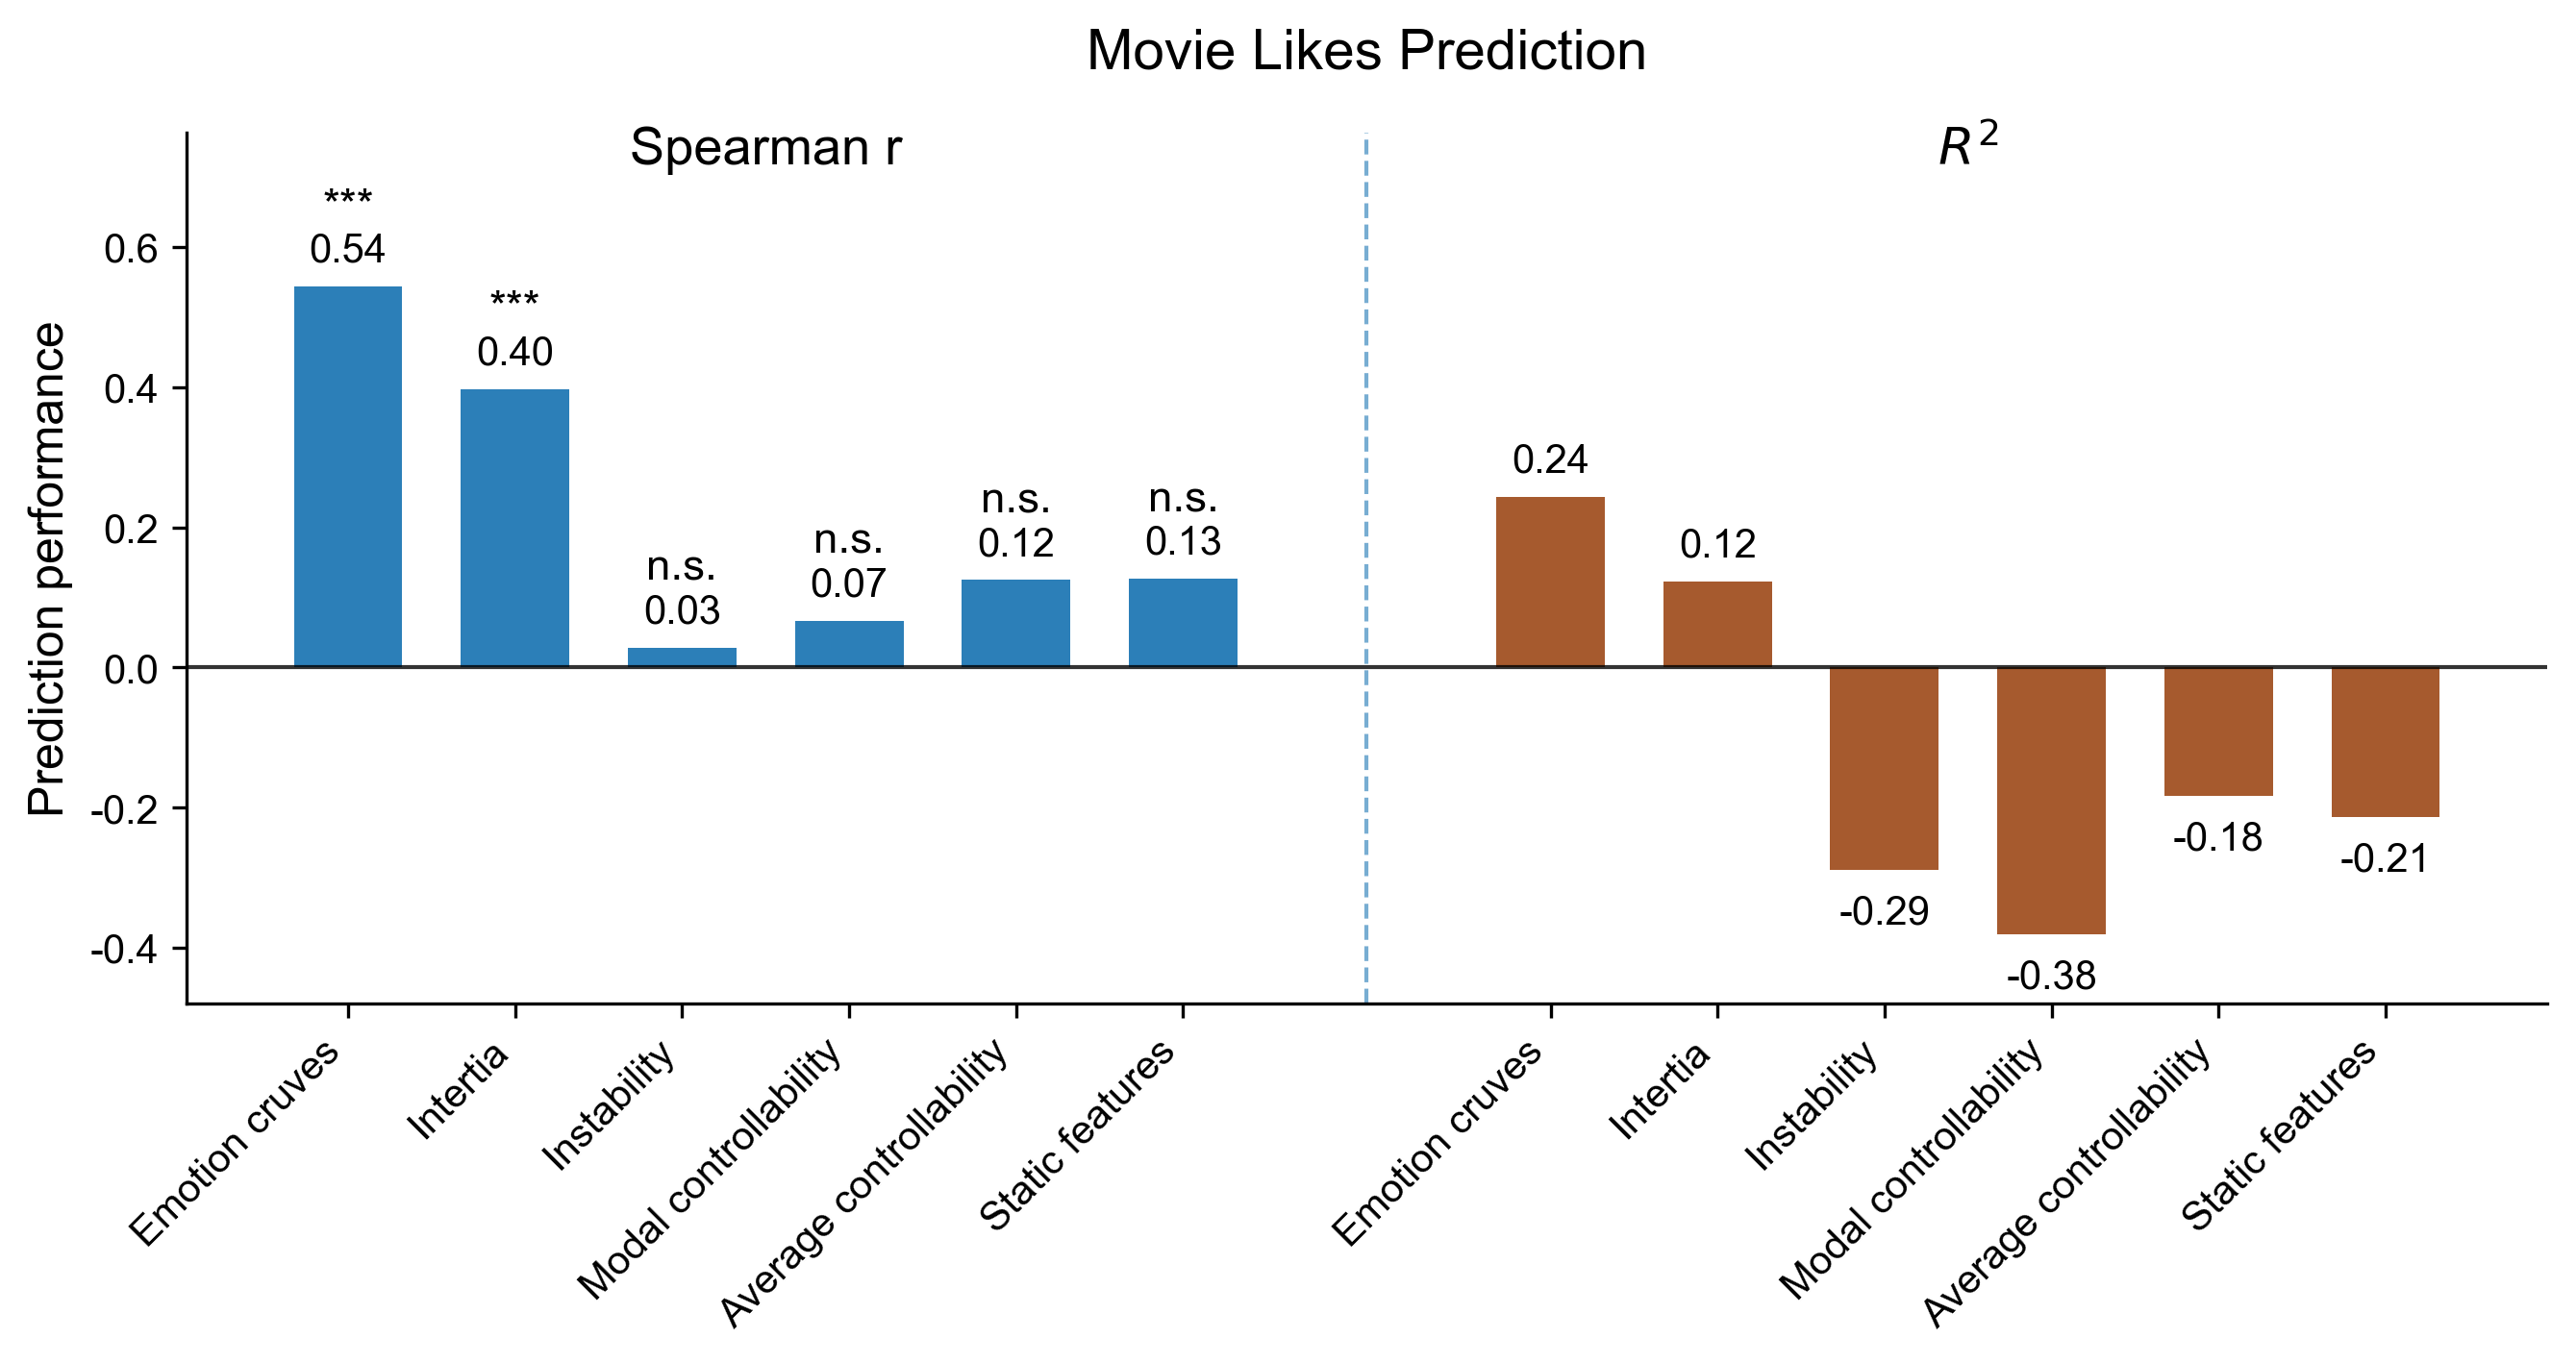

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 数据
# =========================
methods = ["Emotion cruves", "Intertia", "Instability", "Modal controllability", "Average controllability", "Static features"]

# 你的真实结果
pearson_r = np.array(r_list)
r_squared = np.array(r2_list)

# Spearman r 对应的 p 值
p_values = np.array(p_list)

# =========================
# 2. 显著性函数
# =========================
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

sig_labels = [p_to_star(p) for p in p_values]

# =========================
# 3. 设置横坐标
# =========================
x_left = np.arange(len(methods))
gap = 1.2
x_right = x_left + len(methods) + gap

fig, ax = plt.subplots(figsize=(9, 4.8), dpi=300)

bar_width = 0.65

# =========================
# 4. 画柱状图
# =========================
bars_r = ax.bar(
    x_left,
    pearson_r,
    width=bar_width,
    label="Spearman r",
    color="#2C7FB8"
)

bars_r2 = ax.bar(
    x_right,
    r_squared,
    width=bar_width,
    label=r"$R^2$",
    color="#A65A2E"
)

# =========================
# 5. 添加 y=0 基线
# =========================
ax.axhline(
    y=0,
    color="black",
    linewidth=1.0,
    alpha=0.8
)

# =========================
# 6. 添加数值标签
# =========================
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()

        if height >= 0:
            y_text = height + 0.025
            va = "bottom"
        else:
            y_text = height - 0.035
            va = "top"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_text,
            f"{height:.2f}",
            ha="center",
            va=va,
            fontsize=10
        )

add_value_labels(bars_r)
add_value_labels(bars_r2)

# =========================
# 7. 只给 Spearman r 添加显著性标注
# =========================
for bar, star in zip(bars_r, sig_labels):
    height = bar.get_height()

    if height >= 0:
        y_star = height + 0.085
        va = "bottom"
    else:
        y_star = height - 0.085
        va = "top"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_star,
        star,
        ha="center",
        va=va,
        fontsize=11
    )

# =========================
# 8. x 轴标签
# =========================
xticks = np.concatenate([x_left, x_right])
xticklabels = methods + methods

ax.set_xticks(xticks)
ax.set_xticklabels(
    xticklabels,
    rotation=45,
    ha="right",
    fontsize=10
)

# =========================
# 9. 左右两部分标题
# =========================
all_values = np.concatenate([pearson_r, r_squared])
y_max = np.nanmax(all_values)
y_min = np.nanmin(all_values)

y_top = y_max + 0.16

ax.text(
    np.mean(x_left),
    y_top,
    "Spearman r",
    ha="center",
    va="bottom",
    fontsize=13
)

ax.text(
    np.mean(x_right),
    y_top,
    r"$R^2$",
    ha="center",
    va="bottom",
    fontsize=13
)

# 中间分隔线
separator_x = (x_left[-1] + x_right[0]) / 2
ax.axvline(
    separator_x,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

# =========================
# 10. 坐标轴与标题
# =========================
ax.set_ylabel("Prediction performance", fontsize=12)

ax.set_title(
    "Movie Likes Prediction",
    fontsize=14,
    pad=16
)

# 自动设置 y 轴范围，兼容负 R² 和显著性标注
padding_top = 0.22
padding_bottom = 0.10

ax.set_ylim(
    y_min - padding_bottom,
    y_max + padding_top
)

# 去掉上、右边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()

# =========================
# 11. 保存图片
# =========================
plt.savefig("movie_likes_prediction_barplot.png", dpi=300, bbox_inches="tight")
plt.savefig("movie_likes_prediction_barplot.pdf", bbox_inches="tight")

plt.show()

In [55]:
outcomes = ["saves"]


rows = []

idx = 0
for outcome in outcomes:
    for method in methods:
        rows.append({
            "outcome": outcome,
            "method": method,
            "pearson_r": pearson_r[idx],
            "r_squared": r_squared[idx],
            "p_value": p_values[idx]
        })
        idx += 1

df_results = pd.DataFrame(rows)

df_results

,outcome,method,pearson_r,r_squared,p_value
0,saves,Emotion cruves,0.543726,0.243302,0.000999
1,saves,Intertia,0.397420,0.122942,0.000999
2,saves,Instability,0.028327,-0.288643,0.337662
3,saves,Modal controllability,0.066835,-0.380386,0.260739
4,saves,Average controllability,0.124789,-0.183840,0.139860
5,saves,Static features,0.126529,-0.213042,0.209687


In [60]:
p_list

array([0.000999  , 0.000999  , 0.33766234, 0.26073926, 0.13986014,
       0.20968677])

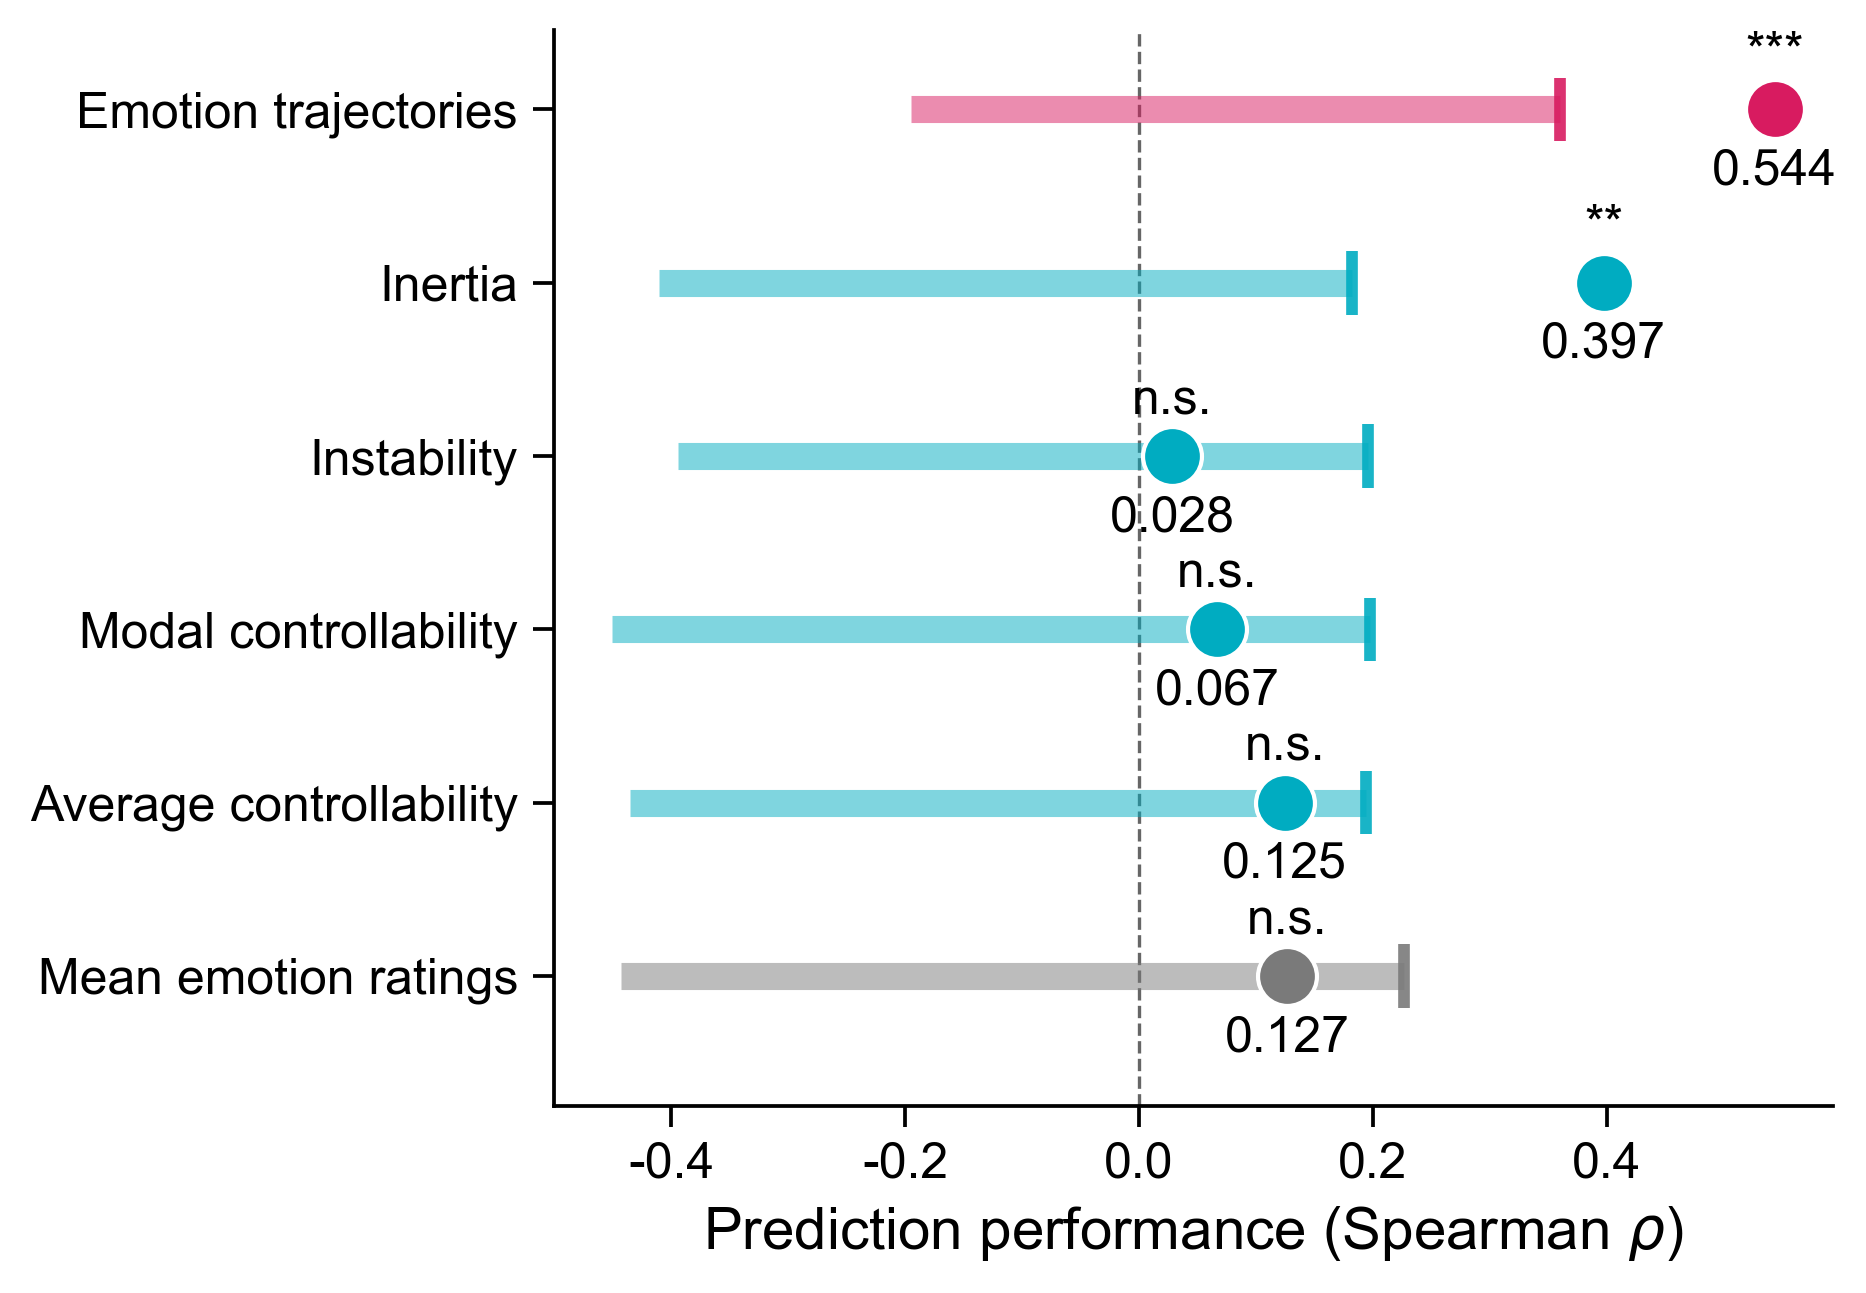

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 13

# ============================================================
# 1. Methods
# ============================================================

methods = [
    "Emotion trajectories",
    "Inertia",
    "Instability",
    "Modal controllability",
    "Average controllability",
    "Mean emotion ratings"
]

# ============================================================
# 2. Colors
# 更饱和一点
# ============================================================

color_trajectory = "#D81B60"   # stronger magenta
color_dynamic    = "#00ACC1"   # stronger cyan-blue
color_static     = "#7A7A7A"   # darker gray

feature_colors = [
    color_trajectory,
    color_dynamic,
    color_dynamic,
    color_dynamic,
    color_dynamic,
    color_static
]

# ============================================================
# 3. Significance
# ============================================================

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# ============================================================
# 4. Plot
# ============================================================

def plot_prediction(
    r_list,
    p_list,
    perm_rho_list,
    save_name,
    xlim=None,
    one_sided=True
):
    values = np.asarray(r_list, dtype=float)
    p_values = np.asarray(p_list, dtype=float)

    # -----------------------------
    # 行间距拉开一点
    # -----------------------------
    y_gap = 1.20
    y_pos = np.arange(len(methods)) * y_gap

    fig, ax = plt.subplots(
        figsize=(6.4, 4.5),
        dpi=300
    )

    # ========================================================
    # rho = 0 reference
    # ========================================================

    ax.axvline(
        0,
        linestyle="--",
        color="black",
        linewidth=0.8,
        alpha=0.60,
        zorder=0
    )

    # ========================================================
    # Plot each feature
    # ========================================================

    for i in range(len(methods)):

        value = values[i]
        p = p_values[i]
        color = feature_colors[i]

        perms = np.asarray(perm_rho_list[i], dtype=float)
        perms = perms[np.isfinite(perms)]

        # ----------------------------------------------------
        # 单侧/双侧 permutation 区间
        # ----------------------------------------------------
        if one_sided:
            perm_low = np.percentile(perms, 0)
            perm_high = np.percentile(perms, 95)
        else:
            perm_low = np.percentile(perms, 2.5)
            perm_high = np.percentile(perms, 97.5)

        # ====================================================
        # Horizontal interval line
        # ====================================================

        ax.plot(
            [perm_low, perm_high],
            [y_pos[i], y_pos[i]],
            color=color,
            linewidth=6.5,
            alpha=0.50,
            solid_capstyle="butt",
            zorder=1
        )

        # ====================================================
        # Right cutoff line
        # ====================================================

        ax.plot(
            [perm_high, perm_high],
            [y_pos[i] - 0.22, y_pos[i] + 0.22],
            color=color,
            linewidth=2.8,
            alpha=0.90,
            solid_capstyle="butt",
            zorder=2
        )

        # ====================================================
        # Observed rho point
        # ====================================================

        ax.scatter(
            value,
            y_pos[i],
            s=200,                 # 更大一点
            color=color,
            edgecolors="white",
            linewidth=1.0,
            zorder=4
        )

        # ====================================================
        # Numeric value
        # 放到点下面
        # ====================================================

        ax.text(
            value,
            y_pos[i] + 0.43,
            f"{value:.3f}",
            va="center",
            ha="center",
            fontsize=12,
            color="black"
        )

        # ====================================================
        # Significance
        # 放到点上面
        # ====================================================

        star = p_to_star(p)

        ax.text(
            value,
            y_pos[i] - 0.38,
            star,
            ha="center",
            va="center",
            fontsize=12,
            color="black"
        )

    # ========================================================
    # Axis
    # ========================================================

    ax.set_yticks(y_pos)
    ax.set_yticklabels(methods, fontsize=13)

    ax.invert_yaxis()

    ax.set_ylim([
        y_pos[-1] + 0.9,
        -0.55
    ])

    # 如果没传 xlim，就自动按数据范围给一点边距
    if xlim is None:
        all_vals = list(values)
        for perms in perm_rho_list:
            perms = np.asarray(perms, dtype=float)
            perms = perms[np.isfinite(perms)]
            if len(perms) > 0:
                all_vals.extend([np.min(perms), np.max(perms)])
        xmin = min(all_vals)
        xmax = max(all_vals)
        pad = 0.05
        ax.set_xlim(xmin - pad, xmax + pad)
    else:
        ax.set_xlim(xlim)

    ax.set_xlabel(
        r"Prediction performance (Spearman $\rho$)",
        fontsize=14
    )

    ax.set_ylabel("")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)

    ax.tick_params(
        axis="both",
        labelsize=12,
        width=0.9,
        length=5
    )

    plt.tight_layout()

    plt.savefig(
        f"{save_name}.svg",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        f"{save_name}.pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 5. Plot
# ============================================================

plot_prediction(
    r_list=r_list,
    p_list=perm_p_list,
    perm_rho_list=perm_rho_list,
    save_name="movie_likes_prediction",
    xlim=None,
    one_sided=True
)

[0.000999000999000999, 0.002997002997002997, 0.8421578421578422, 0.6133866133866134, 0.3706293706293706, 0.4045954045954046] [0, 1, 2, 4, 3, 5]


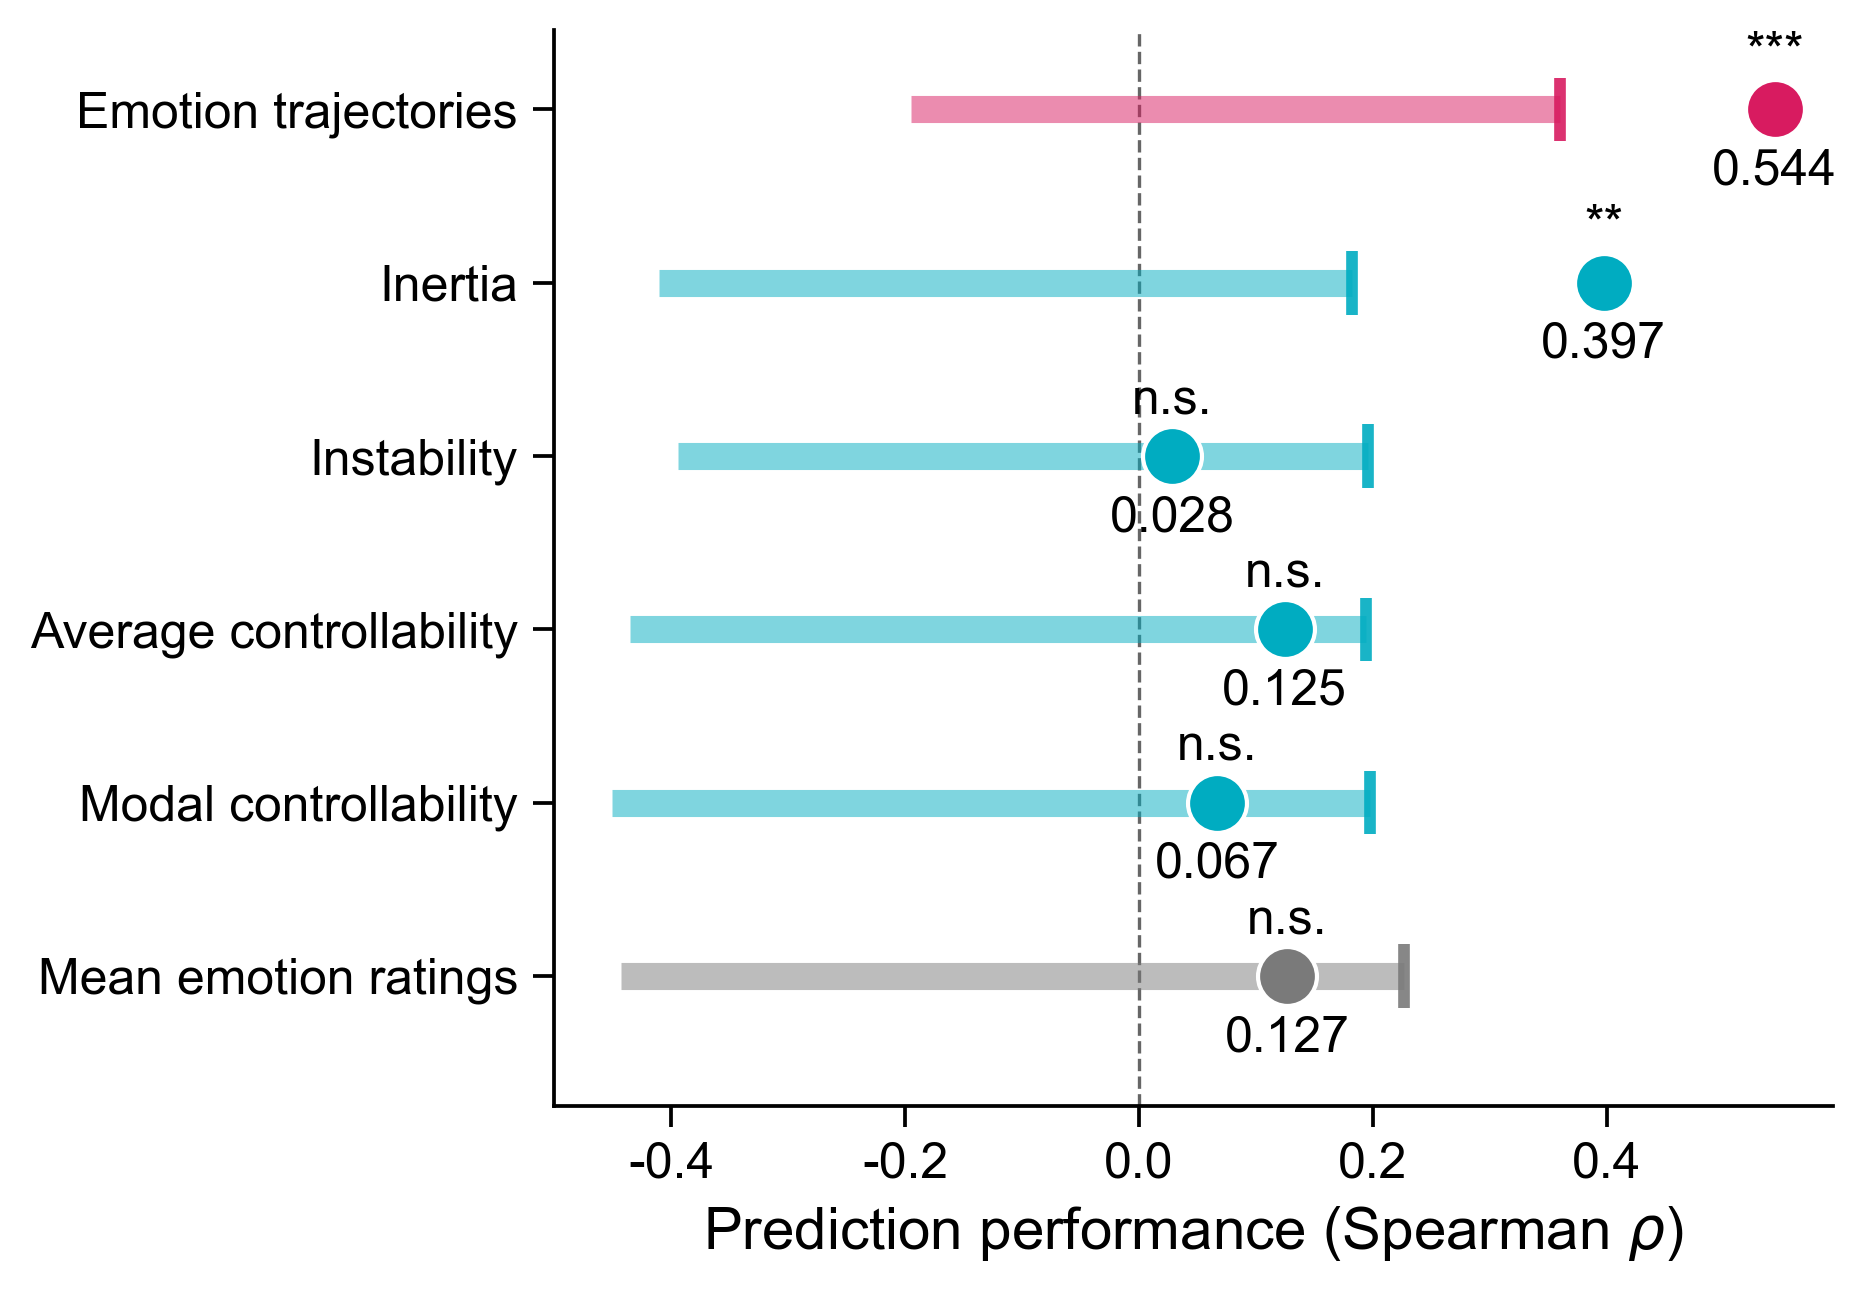

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 13

# ============================================================
# 1. Methods
# ============================================================

methods = [
    "Emotion trajectories",
    "Inertia",
    "Instability",
    "Average controllability",
    "Modal controllability",
    "Mean emotion ratings"
]

# ============================================================
# 2. Colors
# ============================================================

color_trajectory = "#D81B60"
color_dynamic    = "#00ACC1"
color_static     = "#7A7A7A"

feature_colors = [
    color_trajectory,
    color_dynamic,
    color_dynamic,
    color_dynamic,
    color_dynamic,
    color_static
]

# ============================================================
# 3. Significance
# ============================================================

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


# ============================================================
# 4. Reorder function
#
# Original:
# 0 Emotion trajectories
# 1 Inertia
# 2 Instability
# 3 Modal controllability
# 4 Average controllability
# 5 Mean emotion ratings
#
# New:
# 0 Emotion trajectories
# 1 Inertia
# 2 Instability
# 3 Average controllability
# 4 Modal controllability
# 5 Mean emotion ratings
# ============================================================

def reorder_ac_mc(
    r_list,
    p_list,
    perm_rho_list
):
    order = [0, 1, 2, 4, 3, 5]

    r_list_new = [
        r_list[i]
        for i in order
    ]
    print(p_list, order)
    p_list_new = [
        p_list[i]
        for i in order
    ]

    perm_rho_list_new = [
        perm_rho_list[i]
        for i in order
    ]

    return (
        r_list_new,
        p_list_new,
        perm_rho_list_new
    )


# ============================================================
# 5. Plot
# ============================================================

def plot_prediction(
    r_list,
    p_list,
    perm_rho_list,
    save_name,
    xlim=None,
    one_sided=True
):

    # ========================================================
    # Swap Average controllability and Modal controllability
    # ========================================================

    (
        r_list_plot,
        p_list_plot,
        perm_rho_list_plot
    ) = reorder_ac_mc(
        r_list,
        p_list,
        perm_rho_list
    )

    values = np.asarray(
        r_list_plot,
        dtype=float
    )

    p_values = np.asarray(
        p_list_plot,
        dtype=float
    )

    # -----------------------------
    # 行间距
    # -----------------------------

    y_gap = 1.20

    y_pos = (
        np.arange(len(methods))
        * y_gap
    )

    fig, ax = plt.subplots(
        figsize=(6.4, 4.5),
        dpi=300
    )

    # ========================================================
    # rho = 0 reference
    # ========================================================

    ax.axvline(
        0,
        linestyle="--",
        color="black",
        linewidth=0.8,
        alpha=0.60,
        zorder=0
    )

    # ========================================================
    # Plot each feature
    # ========================================================

    for i in range(len(methods)):

        value = values[i]
        p = p_values[i]
        color = feature_colors[i]

        perms = np.asarray(
            perm_rho_list_plot[i],
            dtype=float
        )

        perms = perms[
            np.isfinite(perms)
        ]

        # ----------------------------------------------------
        # 单侧 / 双侧 permutation 区间
        # ----------------------------------------------------

        if one_sided:

            perm_low = np.percentile(
                perms,
                0
            )

            perm_high = np.percentile(
                perms,
                95
            )

        else:

            perm_low = np.percentile(
                perms,
                2.5
            )

            perm_high = np.percentile(
                perms,
                97.5
            )

        # ====================================================
        # Horizontal interval line
        # ====================================================

        ax.plot(
            [perm_low, perm_high],
            [y_pos[i], y_pos[i]],
            color=color,
            linewidth=6.5,
            alpha=0.50,
            solid_capstyle="butt",
            zorder=1
        )

        # ====================================================
        # Right cutoff line
        # ====================================================

        ax.plot(
            [perm_high, perm_high],
            [
                y_pos[i] - 0.22,
                y_pos[i] + 0.22
            ],
            color=color,
            linewidth=2.8,
            alpha=0.90,
            solid_capstyle="butt",
            zorder=2
        )

        # ====================================================
        # Observed rho point
        # ====================================================

        ax.scatter(
            value,
            y_pos[i],
            s=200,
            color=color,
            edgecolors="white",
            linewidth=1.0,
            zorder=4
        )

        # ====================================================
        # Numeric value
        # ====================================================

        ax.text(
            value,
            y_pos[i] + 0.43,
            f"{value:.3f}",
            va="center",
            ha="center",
            fontsize=12,
            color="black"
        )

        # ====================================================
        # Significance
        # ====================================================

        star = p_to_star(p)

        ax.text(
            value,
            y_pos[i] - 0.38,
            star,
            ha="center",
            va="center",
            fontsize=12,
            color="black"
        )

    # ========================================================
    # Axis
    # ========================================================

    ax.set_yticks(
        y_pos
    )

    ax.set_yticklabels(
        methods,
        fontsize=13
    )

    ax.invert_yaxis()

    ax.set_ylim([
        y_pos[-1] + 0.9,
        -0.55
    ])

    # ========================================================
    # X-axis range
    # ========================================================

    if xlim is None:

        all_vals = list(values)

        for perms in perm_rho_list_plot:

            perms = np.asarray(
                perms,
                dtype=float
            )

            perms = perms[
                np.isfinite(perms)
            ]

            if len(perms) > 0:

                all_vals.extend([
                    np.min(perms),
                    np.max(perms)
                ])

        xmin = min(all_vals)
        xmax = max(all_vals)

        pad = 0.05

        ax.set_xlim(
            xmin - pad,
            xmax + pad
        )

    else:

        ax.set_xlim(
            xlim
        )

    ax.set_xlabel(
        r"Prediction performance (Spearman $\rho$)",
        fontsize=14
    )

    ax.set_ylabel("")

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    ax.spines[
        "left"
    ].set_linewidth(0.9)

    ax.spines[
        "bottom"
    ].set_linewidth(0.9)

    ax.tick_params(
        axis="both",
        labelsize=12,
        width=0.9,
        length=5
    )

    plt.tight_layout()

    # ========================================================
    # Save
    # ========================================================

    plt.savefig(
        f"{save_name}.svg",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        f"{save_name}.pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 6. Plot
# ============================================================

plot_prediction(
    r_list=r_list,
    p_list=perm_p_list,
    perm_rho_list=perm_rho_list,
    save_name="movie_likes_prediction",
    xlim=None,
    one_sided=True
)

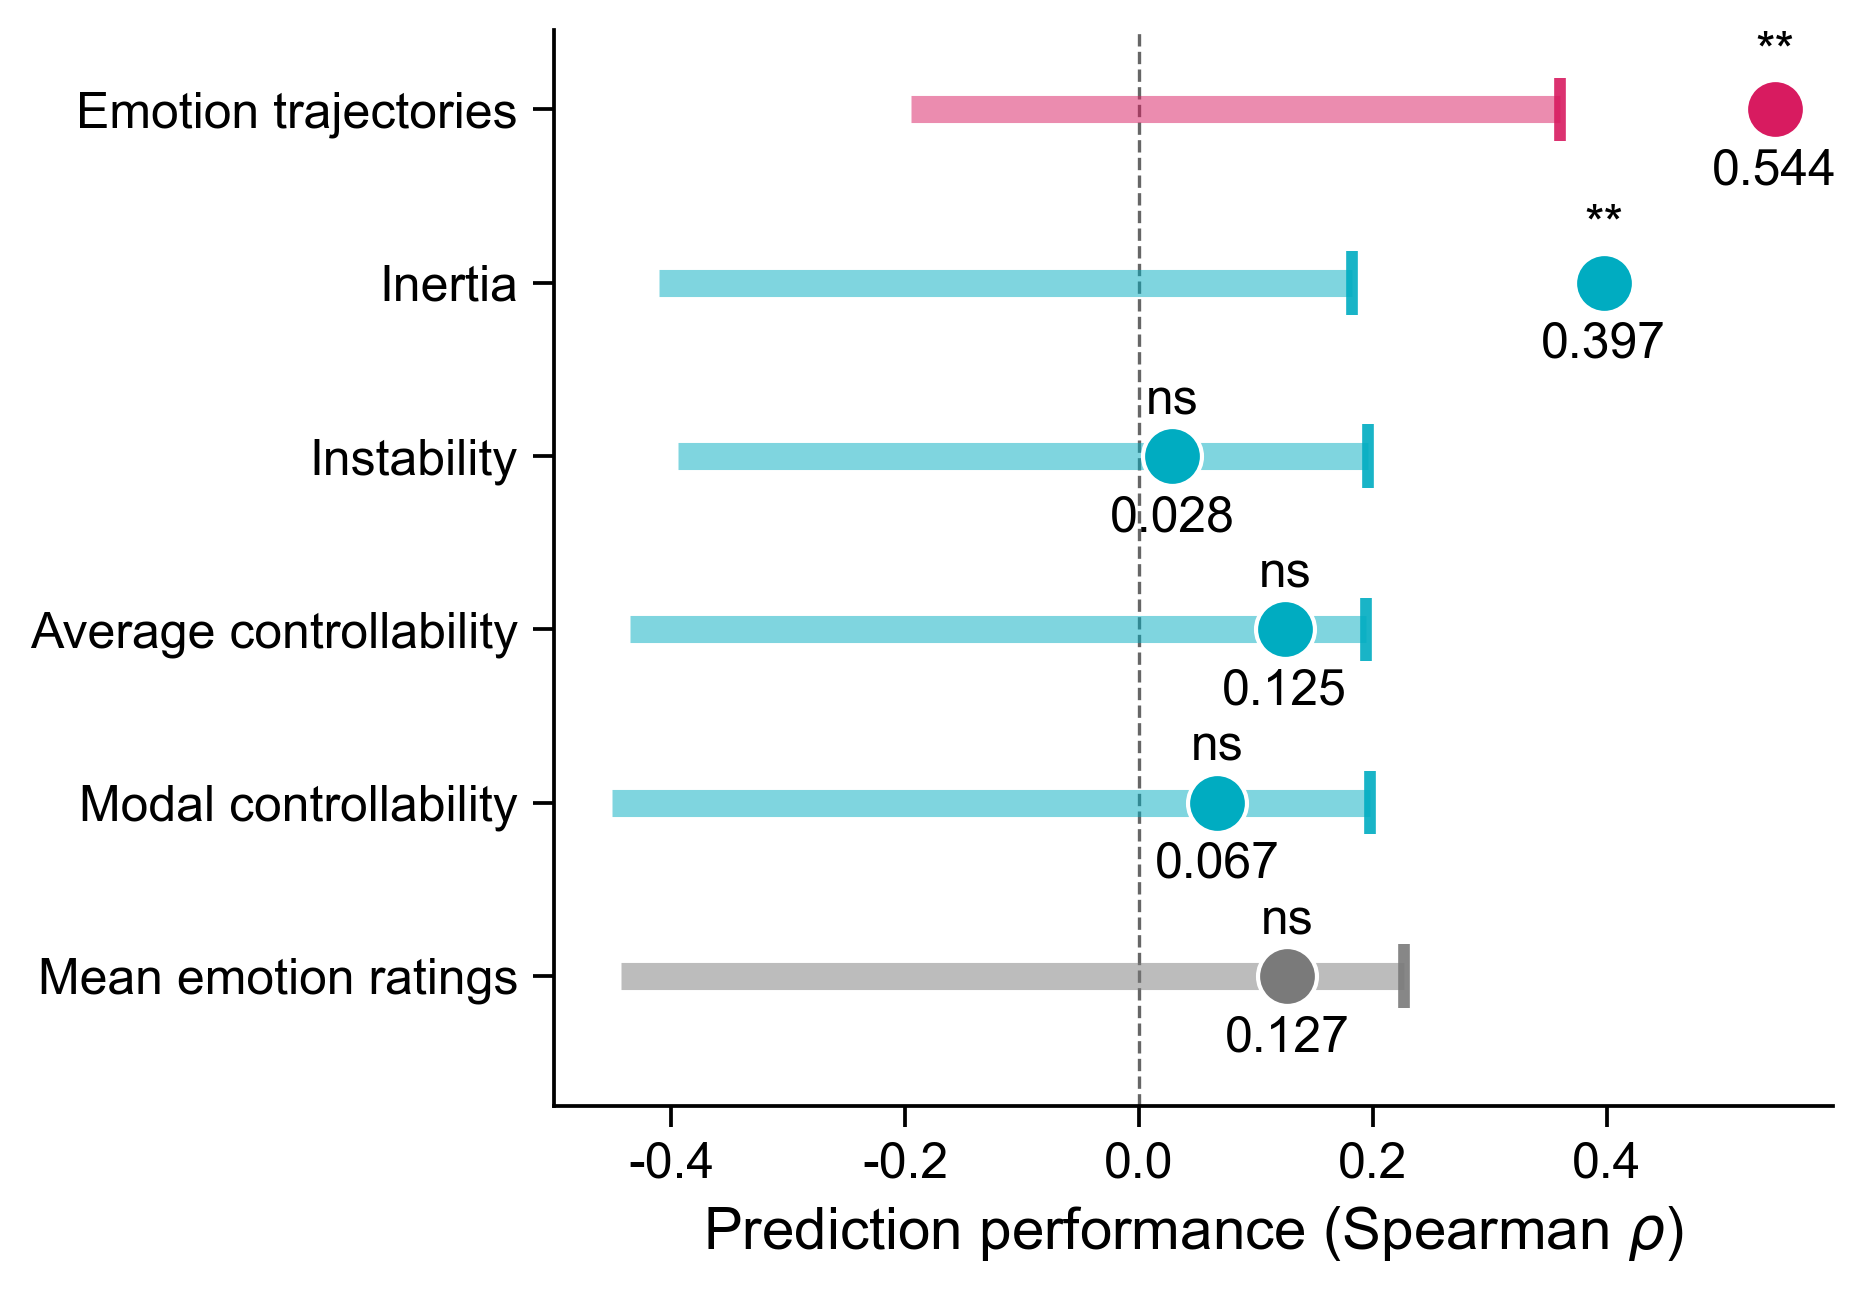

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 13


# ============================================================
# 1. Methods
# ============================================================

methods = [
    "Emotion trajectories",
    "Inertia",
    "Instability",
    "Average controllability",
    "Modal controllability",
    "Mean emotion ratings"
]


# ============================================================
# 2. Colors
# ============================================================

color_trajectory = "#D81B60"
color_dynamic    = "#00ACC1"
color_static     = "#7A7A7A"

feature_colors = [
    color_trajectory,
    color_dynamic,
    color_dynamic,
    color_dynamic,
    color_dynamic,
    color_static
]


# ============================================================
# 3. Significance
# ============================================================

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


# ============================================================
# 4. Reorder AC and MC
#
# Original:
# 0 Emotion trajectories
# 1 Inertia
# 2 Instability
# 3 Modal controllability
# 4 Average controllability
# 5 Mean emotion ratings
#
# New:
# 0 Emotion trajectories
# 1 Inertia
# 2 Instability
# 3 Average controllability
# 4 Modal controllability
# 5 Mean emotion ratings
# ============================================================

def reorder_ac_mc(
    r_list,
    p_list,
    perm_rho_list
):

    order = [0, 1, 2, 4, 3, 5]

    r_list_new = [
        r_list[i]
        for i in order
    ]

    p_list_new = [
        p_list[i]
        for i in order
    ]

    perm_rho_list_new = [
        perm_rho_list[i]
        for i in order
    ]

    return (
        r_list_new,
        p_list_new,
        perm_rho_list_new
    )


# ============================================================
# 5. Plot
# ============================================================

def plot_prediction(
    r_list,
    p_list,
    perm_rho_list,
    save_name,
    xlim=None,
    one_sided=True
):

    # ========================================================
    # Reorder AC and MC
    # ========================================================

    (
        r_list_plot,
        p_list_plot,
        perm_rho_list_plot
    ) = reorder_ac_mc(
        r_list,
        p_list,
        perm_rho_list
    )

    values = np.asarray(
        r_list_plot,
        dtype=float
    )

    p_values = np.asarray(
        p_list_plot,
        dtype=float
    )


    # ========================================================
    # BH-FDR correction across the 6 prediction methods
    # ========================================================

    valid = np.isfinite(p_values)

    q_values = np.full_like(
        p_values,
        np.nan,
        dtype=float
    )

    _, q_values[valid], _, _ = multipletests(
        p_values[valid],
        alpha=0.05,
        method="fdr_bh"
    )


    # ========================================================
    # Y positions
    # ========================================================

    y_gap = 1.20

    y_pos = (
        np.arange(len(methods))
        * y_gap
    )


    # ========================================================
    # Figure
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(6.4, 4.5),
        dpi=300
    )


    # ========================================================
    # rho = 0 reference
    # ========================================================

    ax.axvline(
        0,
        linestyle="--",
        color="black",
        linewidth=0.8,
        alpha=0.60,
        zorder=0
    )


    # ========================================================
    # Plot each feature
    # ========================================================

    for i in range(len(methods)):

        value = values[i]

        # 注意：这里使用 FDR-adjusted q
        q = q_values[i]

        color = feature_colors[i]

        perms = np.asarray(
            perm_rho_list_plot[i],
            dtype=float
        )

        perms = perms[
            np.isfinite(perms)
        ]


        # ----------------------------------------------------
        # Permutation interval
        # ----------------------------------------------------

        if one_sided:

            perm_low = np.percentile(
                perms,
                0
            )

            perm_high = np.percentile(
                perms,
                95
            )

        else:

            perm_low = np.percentile(
                perms,
                2.5
            )

            perm_high = np.percentile(
                perms,
                97.5
            )


        # ====================================================
        # Horizontal permutation interval
        # ====================================================

        ax.plot(
            [perm_low, perm_high],
            [y_pos[i], y_pos[i]],
            color=color,
            linewidth=6.5,
            alpha=0.50,
            solid_capstyle="butt",
            zorder=1
        )


        # ====================================================
        # Right cutoff
        # ====================================================

        ax.plot(
            [perm_high, perm_high],
            [
                y_pos[i] - 0.22,
                y_pos[i] + 0.22
            ],
            color=color,
            linewidth=2.8,
            alpha=0.90,
            solid_capstyle="butt",
            zorder=2
        )


        # ====================================================
        # Observed rho
        # ====================================================

        ax.scatter(
            value,
            y_pos[i],
            s=200,
            color=color,
            edgecolors="white",
            linewidth=1.0,
            zorder=4
        )


        # ====================================================
        # Numeric rho
        # ====================================================

        ax.text(
            value,
            y_pos[i] + 0.43,
            f"{value:.3f}",
            va="center",
            ha="center",
            fontsize=12,
            color="black"
        )


        # ====================================================
        # Significance
        # FDR-adjusted q-value
        # ====================================================

        star = p_to_star(q)

        ax.text(
            value,
            y_pos[i] - 0.38,
            star,
            ha="center",
            va="center",
            fontsize=12,
            color="black"
        )


    # ========================================================
    # Axis
    # ========================================================

    ax.set_yticks(
        y_pos
    )

    ax.set_yticklabels(
        methods,
        fontsize=13
    )

    ax.invert_yaxis()

    ax.set_ylim([
        y_pos[-1] + 0.9,
        -0.55
    ])


    # ========================================================
    # X-axis range
    # ========================================================

    if xlim is None:

        all_vals = list(values)

        for perms in perm_rho_list_plot:

            perms = np.asarray(
                perms,
                dtype=float
            )

            perms = perms[
                np.isfinite(perms)
            ]

            if len(perms) > 0:

                all_vals.extend([
                    np.min(perms),
                    np.max(perms)
                ])

        xmin = min(all_vals)
        xmax = max(all_vals)

        pad = 0.05

        ax.set_xlim(
            xmin - pad,
            xmax + pad
        )

    else:

        ax.set_xlim(
            xlim
        )


    # ========================================================
    # Labels
    # ========================================================

    ax.set_xlabel(
        r"Prediction performance (Spearman $\rho$)",
        fontsize=14
    )

    ax.set_ylabel("")


    # ========================================================
    # Style
    # ========================================================

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)

    ax.tick_params(
        axis="both",
        labelsize=12,
        width=0.9,
        length=5
    )


    # ========================================================
    # Layout
    # ========================================================

    plt.tight_layout()


    # ========================================================
    # Save
    # ========================================================

    plt.savefig(
        f"{save_name}.svg",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        f"{save_name}.pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # 返回校正后的 q，方便后续保存
    return q_values


# ============================================================
# 6. Plot
# ============================================================

q_list = plot_prediction(
    r_list=r_list,
    p_list=perm_p_list,
    perm_rho_list=perm_rho_list,
    save_name="movie_likes_prediction",
    xlim=None,
    one_sided=True
)